# **Librerias**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency

from sklearn.preprocessing import PowerTransformer

from sklearn.feature_selection import mutual_info_regression


# **Lectura de los datos y Unión de DataFrames**

Primero de todo, leemos los .csv para poder trabajar con ellos en dataframes.

In [2]:
df_stores = pd.read_csv("../data/raw/stores.csv")
df_holidays = pd.read_csv("../data/raw/holidays_events.csv")
df_oil = pd.read_csv("../data/raw/oil.csv")
df_transactions = pd.read_csv("../data/raw/transactions.csv")
df_train= pd.read_csv("../data/raw/train.csv")

A continuación, leemos uno a uno, con el fin de poder saber qué tipo de datos vamos a analizar y saber qué campo que relacionar entre ellas para juntar todos los .csv en un único dataframe.

In [3]:
print("-----------------")
print("Stores")
df_stores.info()
df_stores.head()

-----------------
Stores
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [4]:
print("-----------------")
print("Holidays")
df_holidays.info()
df_holidays.head()

-----------------
Holidays
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [5]:
print("-----------------")
print("Oil")
df_oil.info()
df_oil.head()

-----------------
Oil
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
print("-----------------")
print("Transactions")
df_transactions.info()
df_transactions.head()

-----------------
Transactions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [7]:
print("-----------------")
print("Train Dataset")
df_train.info()
df_train.head()


-----------------
Train Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Procedemos con la unión de los .csv en dataframes con la función .merge, donde le pasamos como parámetro el campo a unir y el tipo de join, en nuestro caso hemos optado por el left, ya que queremos mostrar del primer dataframe (izquierda).

In [8]:
df_final = pd.merge(df_train, df_stores, on='store_nbr', how='left')

df_final = pd.merge(df_final, df_transactions, on=['date', 'store_nbr'], how='left')

df_final = pd.merge(df_final, df_oil, on='date', how='left')

df_final = pd.merge(df_final, df_holidays, on='date', how='left')



Hemos detectado que el campo 'date', no es reconocido como fecha, por lo que como primera transfromación de los datos es cambiar el campo 'date' como fecha. Además, hemos creado nuevas columnas utilizando el campo 'date' como referencia (año, mes, día de la semana y si es finde semana o no), ya que el tráfico de clientes de una tienda podría cambiar en función del día de la semana.

In [9]:
df_final['date'] = pd.to_datetime(df_final['date'])
df_final =df_final.sort_values('date').reset_index(drop=True)

En cuanto a la partición entre el df_train y el df_test, al tener datos en una serie temporal, la división de estos se lleva a cabo a través de la fecha. En donde los datos inferiores al 2017 se asignan al df_train y aquellos superiores o igual a la fecha de corte se asignan al df_test para comprobar la capacidad predictiva del modelo.

In [10]:
fecha_corte = '2017-01-01'
# idx = int(0.8 * df_final.shape[0])
# df_train = df_final.iloc[:idx, :]
# df_test = df_final.iloc[idx:, :]

df_train = df_final[df_final['date']< fecha_corte]
df_test = df_final[df_final['date'] >= fecha_corte]

df_train.to_csv("../data/raw/df_train.csv",index=False)
df_test.to_csv("../data/raw/df_test.csv",index=False)

In [11]:
#Comprobación de que la partición haya salido con éxtio
df_train['date'].min(), df_train['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2016-12-31 00:00:00'))

In [12]:
#Comprobación de que la partición haya salido con éxtio
df_test['date'].min(), df_test['date'].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

Comprobar que el peso de cada partición sea óptimo, es decir, el porcentaje de partición de los datos de la serie temporal.

In [13]:
print(f"% Train: {df_train.shape[0]/df_final.shape[0]} , % Test: {df_test.shape[0]/df_final.shape[0]}")

% Train: 0.8652275379229871 , % Test: 0.13477246207701282


# **Exploración de los datos**

Una vez obtenido el df_final, con todas las columnas en un único dataframe, vamos a observar los datos detalladamente.

In [14]:
df_train

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1194,2013-01-01,42,CELEBRATION,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,1192,2013-01-01,42,BOOKS,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,1191,2013-01-01,42,BEVERAGES,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2642701,2595184,2016-12-31,25,SCHOOL AND OFFICE SUPPLIES,0.000,0,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2642702,2595185,2016-12-31,25,SEAFOOD,29.634,1,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2642703,2595186,2016-12-31,26,AUTOMOTIVE,13.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2642704,2595187,2016-12-31,26,BABY CARE,0.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False


En primer lugar, detectamos que hay nombres que cuestan entenderlos, por lo que vamos a cambiar el nombre de estas y asi facilitar a la hora de analizarlos. Tanto en el df_train como el df_test.

In [15]:
df_train.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)
df_test.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2818501641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2818501641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)


Ahora una vez, renombrado las columnas, vamos a comprobar que los tipos de las variables son correctos. En nuestro caso, hemos visto que hay variables que deberían tratarse como categóricas, en cambio en el dataframe inicial se detectan como numéricas.

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2642706 entries, 0 to 2642705
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type_store    object        
 9   cluster       int64         
 10  transactions  float64       
 11  oil_price     float64       
 12  type_holiday  object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 362.9+ MB


In [17]:
df_train.shape

(2642706, 17)

Eliminamos las columnas 'id' y 'store_nbr' ya que son identificadores únicos, y no son relevantes para la exploración ni para el modelo

In [18]:
df_train.drop(columns = ['id','store_nbr'], inplace = True)

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2867874391.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.drop(columns = ['id','store_nbr'], inplace = True)


Procedemos a dividir el dataframe en un lista con las columnas categóricas y numéricas, previas a su análisis individual

In [19]:
categoric_cols = df_train.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = df_train.select_dtypes(include = [np.number]).columns.tolist()

print(f"Variables categóricas {categoric_cols}")
print("--------------------------------")
print(f"Variables numéricas {numeric_cols}")

Variables categóricas ['family', 'city', 'state', 'type_store', 'type_holiday', 'locale', 'locale_name', 'description', 'transferred']
--------------------------------
Variables numéricas ['sales', 'onpromotion', 'cluster', 'transactions', 'oil_price']


In [20]:
df_train[numeric_cols].describe(percentiles= [.25 , .5, .75, .9, .95, .99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
sales,2642706.0,339.994847,1061.583133,0.00,0.00,9.00,185.0,822.00,1852.00,5263.0,124717.00
onpromotion,2642706.0,1.963957,11.038151,0.00,0.00,0.00,0.0,2.00,8.00,49.0,741.00
cluster,2642706.0,8.481481,4.649735,1.00,4.00,8.50,13.0,15.00,15.00,17.0,17.00
transactions,2398935.0,1704.314726,972.020822,5.00,1049.00,1399.00,2103.0,3079.00,3724.00,4905.0,8359.00
oil_price,1822986.0,70.838446,26.420837,26.19,46.28,60.01,97.1,103.54,105.88,108.0,110.62


In [21]:
df_train[categoric_cols].describe(include='object').T

,count,unique,top,freq
family,2642706,33,AUTOMOTIVE,80082
city,2642706,22,Quito,880902
state,2642706,16,Pichincha,929841
type_store,2642706,5,D,880902
type_holiday,449064,6,Holiday,265518
locale,449064,3,National,240570
locale_name,449064,24,Ecuador,240570
description,449064,100,Carnaval,14256
transferred,449064,2,False,440154


In [22]:
df_train.isnull().sum()

date                  0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_store            0
cluster               0
transactions     243771
oil_price        819720
type_holiday    2193642
locale          2193642
locale_name     2193642
description     2193642
transferred     2193642
dtype: int64

In [23]:
nulos_por_variable = ((df_train.isnull().sum() / df_train.shape[0]) * 100).round(2)

print(nulos_por_variable)

date             0.00
family           0.00
sales            0.00
onpromotion      0.00
city             0.00
state            0.00
type_store       0.00
cluster          0.00
transactions     9.22
oil_price       31.02
type_holiday    83.01
locale          83.01
locale_name     83.01
description     83.01
transferred     83.01
dtype: float64


Al haber detectado algunas columnas, que se deberían tratar como categóricas, procedemos a hacer los cambios. La principal razón por la que se deben tratar como categórica y no como numérica es porque al ser variables de identificación queremos que se traten de manera equitativa.

In [24]:
df_train = df_train.astype({'transferred': 'bool'})
df_test = df_test.astype({'transferred': 'bool'})

# **Análisis Univariable**

## **1. Columnas numéricas**

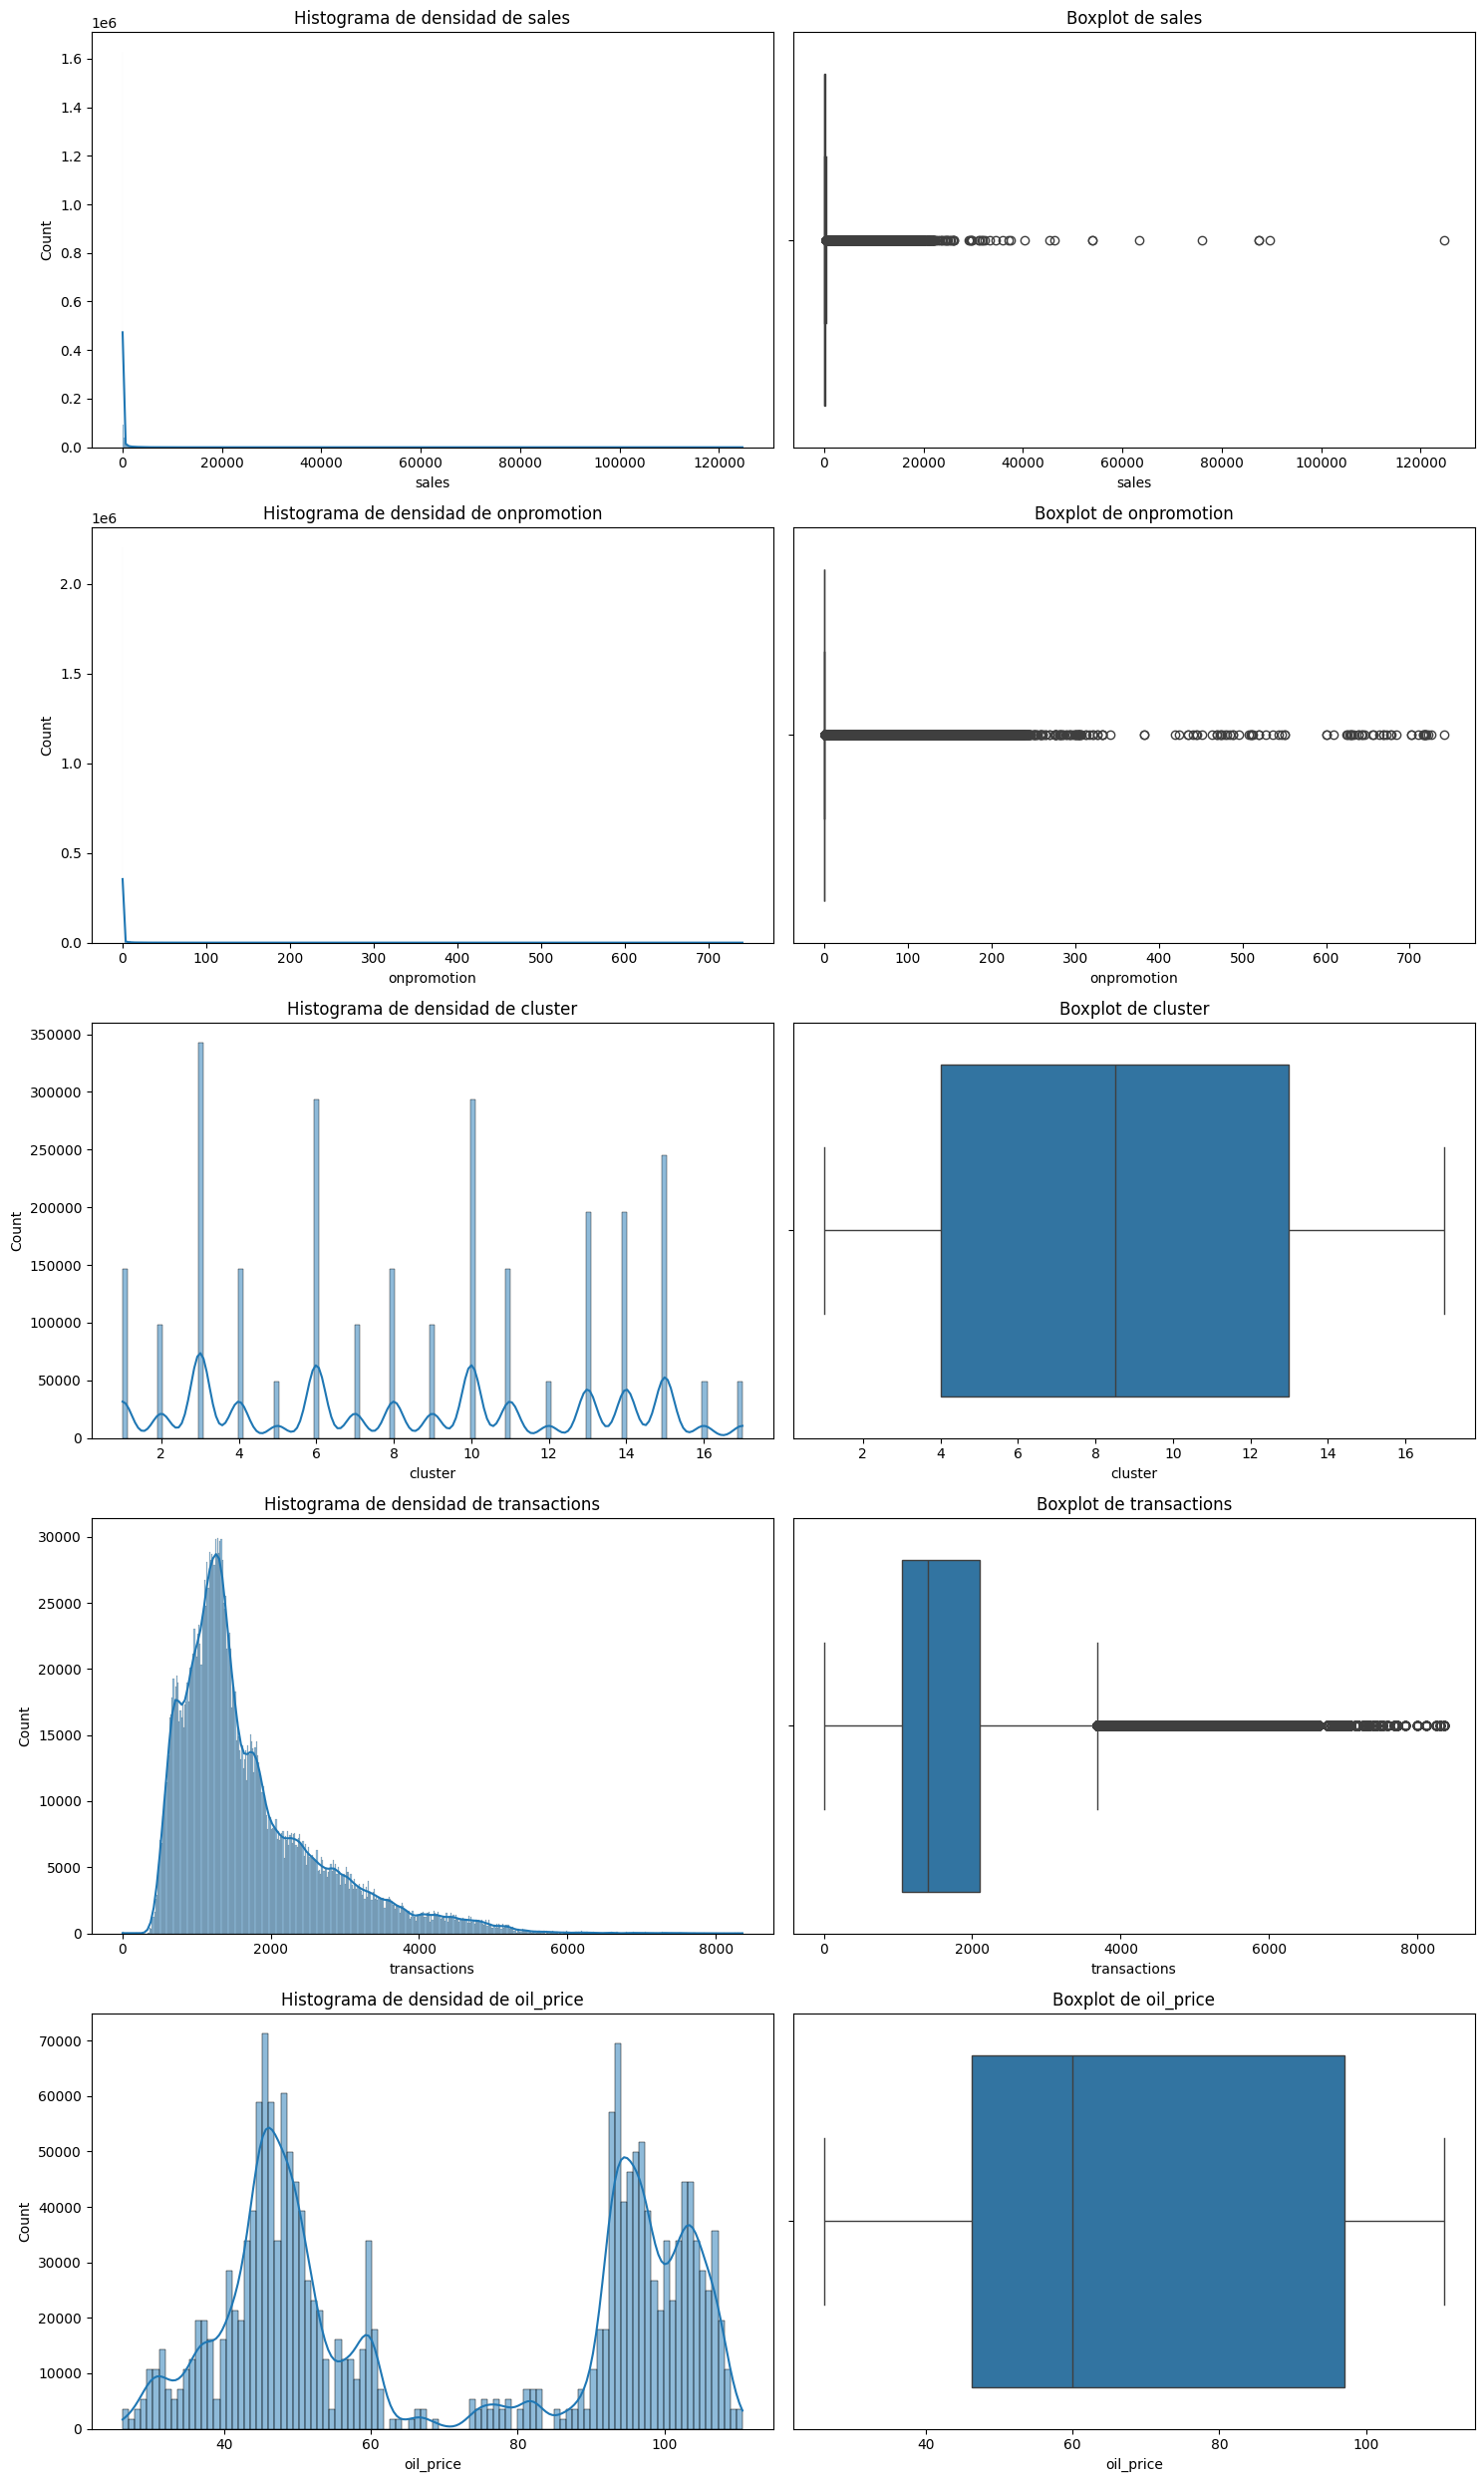

In [25]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 5 * len(numeric_cols)))

for i, column in enumerate(df_train[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df_train[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_train[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

In [26]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    perc = (len(outliers) / len(df_train)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
sales: 395096 registros (14.95%)
onpromotion: 439508 registros (16.63%)
cluster: 0 registros (0.00%)
transactions: 125301 registros (4.74%)
oil_price: 0 registros (0.00%)


## **Exploración de outliers**

Detectamos muchos outliers en las siguientes variables: 'sales', 'on_promotion' y 'transaction'. 

1. No podemos observar la distribución de la variable 'onpromotion', ya que al estar hablando de la cantidad de productos que se han comprado con promoción, es probable que las ventas que no tienen promoción (suponemos que es la gran mayoría) pueden distorsionar la distribución de la variable. Por lo que vamos a filtrarlo 'onpromotion'>1.
2. Observamos que la variable 'sales', tiene muchísimos outliers (14,95%) por lo que hemos planteado en implementar un logaritmo para poder apreciar la distribución y reducir el impacto de los outliers.
3. Para la variable 'transaction', vamos a implementar el Yeo Johnson para normalizar la distribución.

**Histograma y Boxplot de Sales**

Vamos a imputarle un logaritmo como hemos dicho previamente.

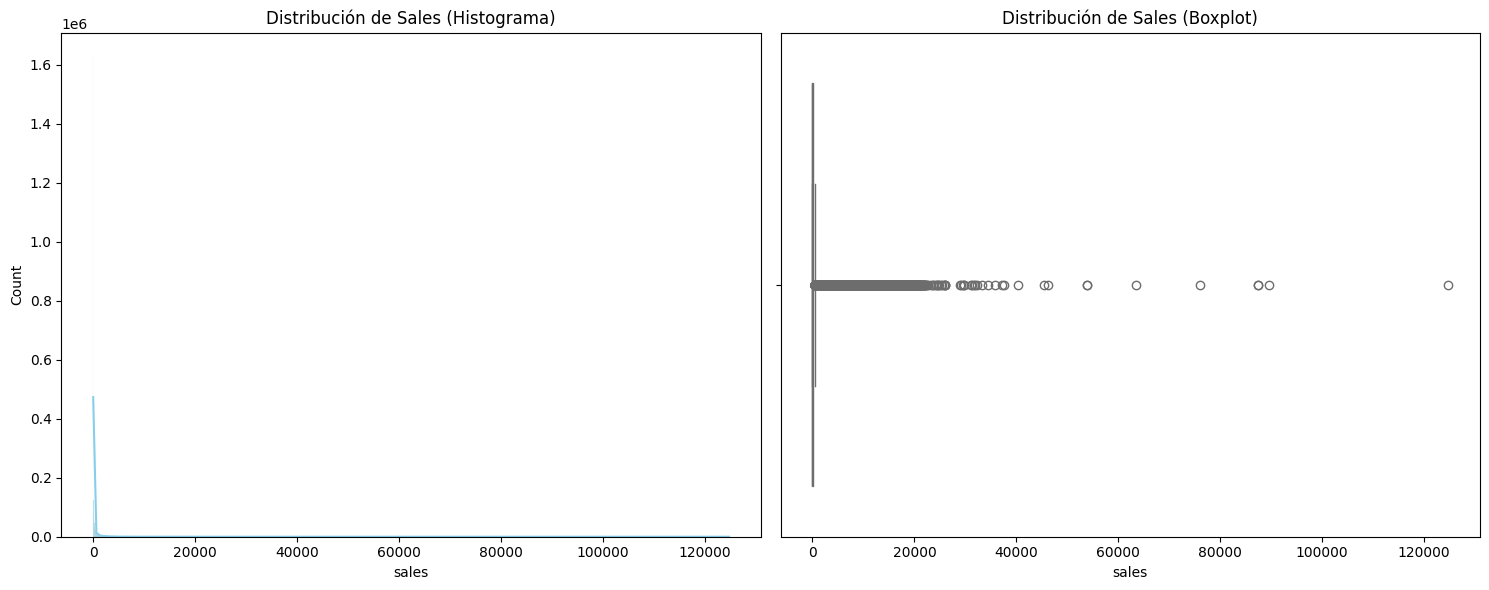

In [27]:
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_train['sales'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Sales (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_train['sales'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Sales (Boxplot)')

plt.tight_layout()
plt.show()

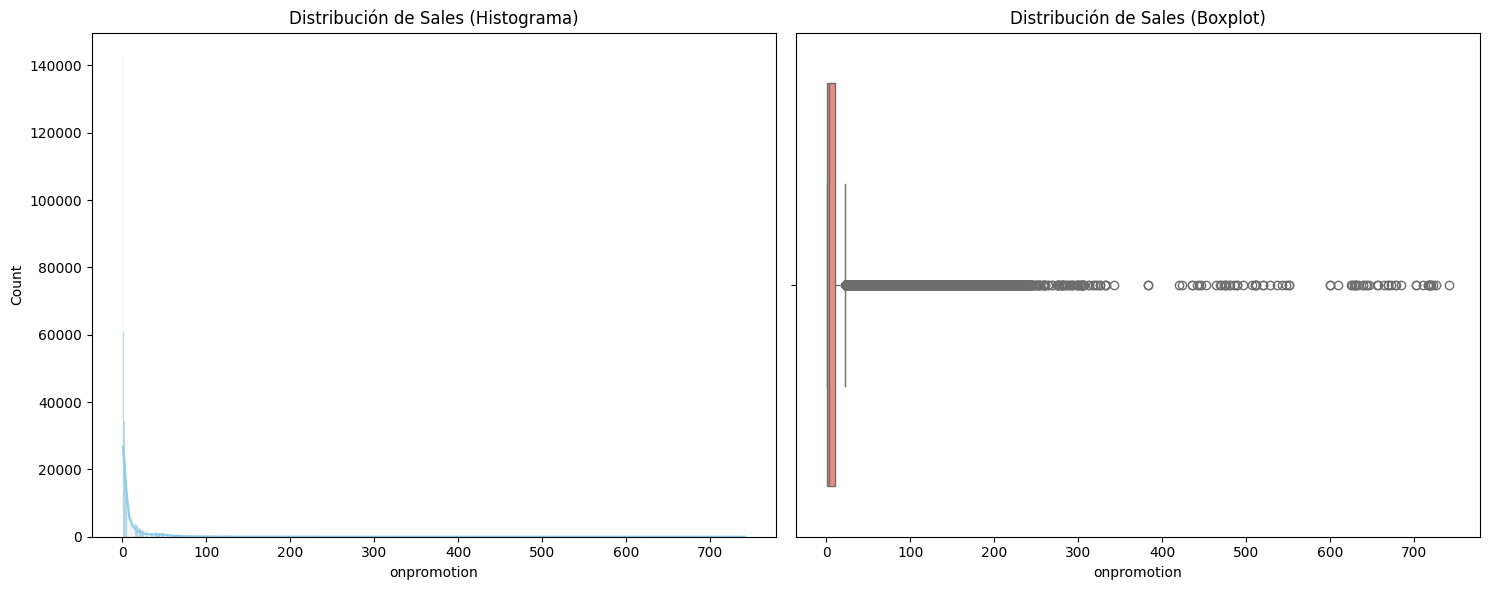

In [28]:
# 1. Filtramos los datos (solo filas donde hay promoción)
df_promote = df_train[df_train['onpromotion']>=1].copy()
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_promote['onpromotion'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Sales (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_promote['onpromotion'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Sales (Boxplot)')

plt.tight_layout()
plt.show()

**Aplicamos Logaritmos a las variables de 'onpromotion' y 'sales'**

In [29]:
log_cols = ['onpromotion','sales']

for c in log_cols:
    df_promote[c + '_log'] = np.log1p(df_promote[c])

df_promote[log_cols] = np.log1p(df_promote[log_cols])


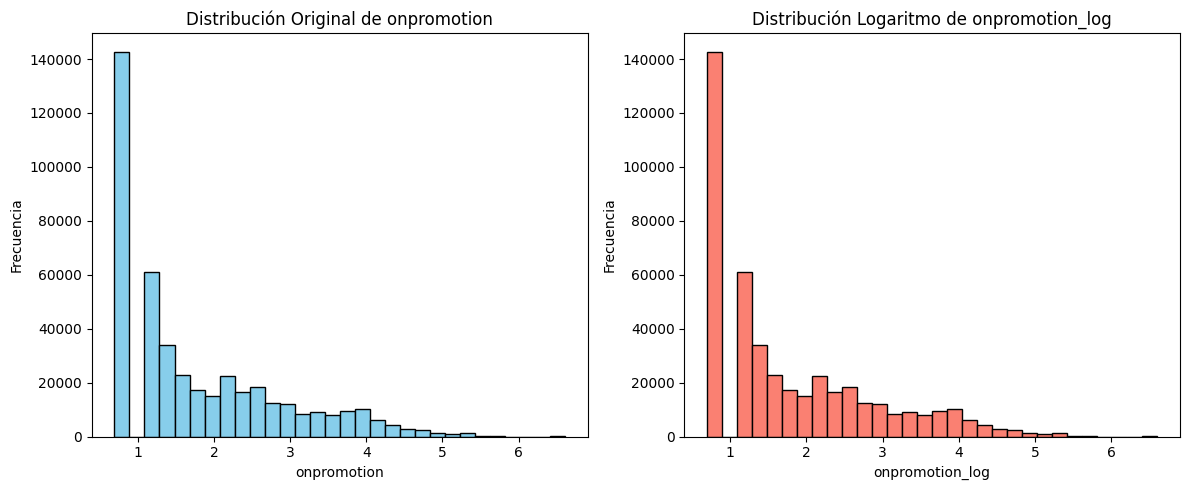

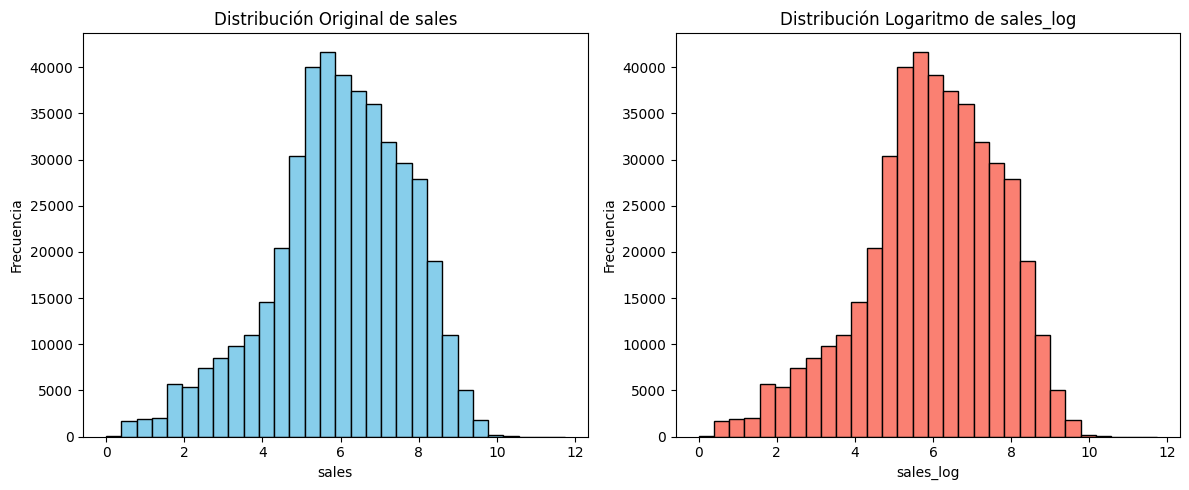

In [30]:
cols_to_plot = [
    ('onpromotion', 'onpromotion_log'),
    ('sales', 'sales_log'),
]

# Iniciamos el bucle
for col_orig, col_log in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # 1. Histograma Original
    plt.subplot(1, 2, 1)
    plt.hist(df_promote[col_orig], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribución Original de {col_orig}")
    plt.xlabel(col_orig)
    plt.ylabel("Frecuencia")
    
    # 2. Histograma Transformado
    plt.subplot(1, 2, 2)
    plt.hist(df_promote[col_log], bins=30, color="salmon", edgecolor="black")
    plt.title(f"Distribución Logaritmo de {col_log}")
    plt.xlabel(col_log)
    plt.ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

**Vemos el histograma y el boxplot de nuevo solamente para 'sales' y 'onpromotion'**

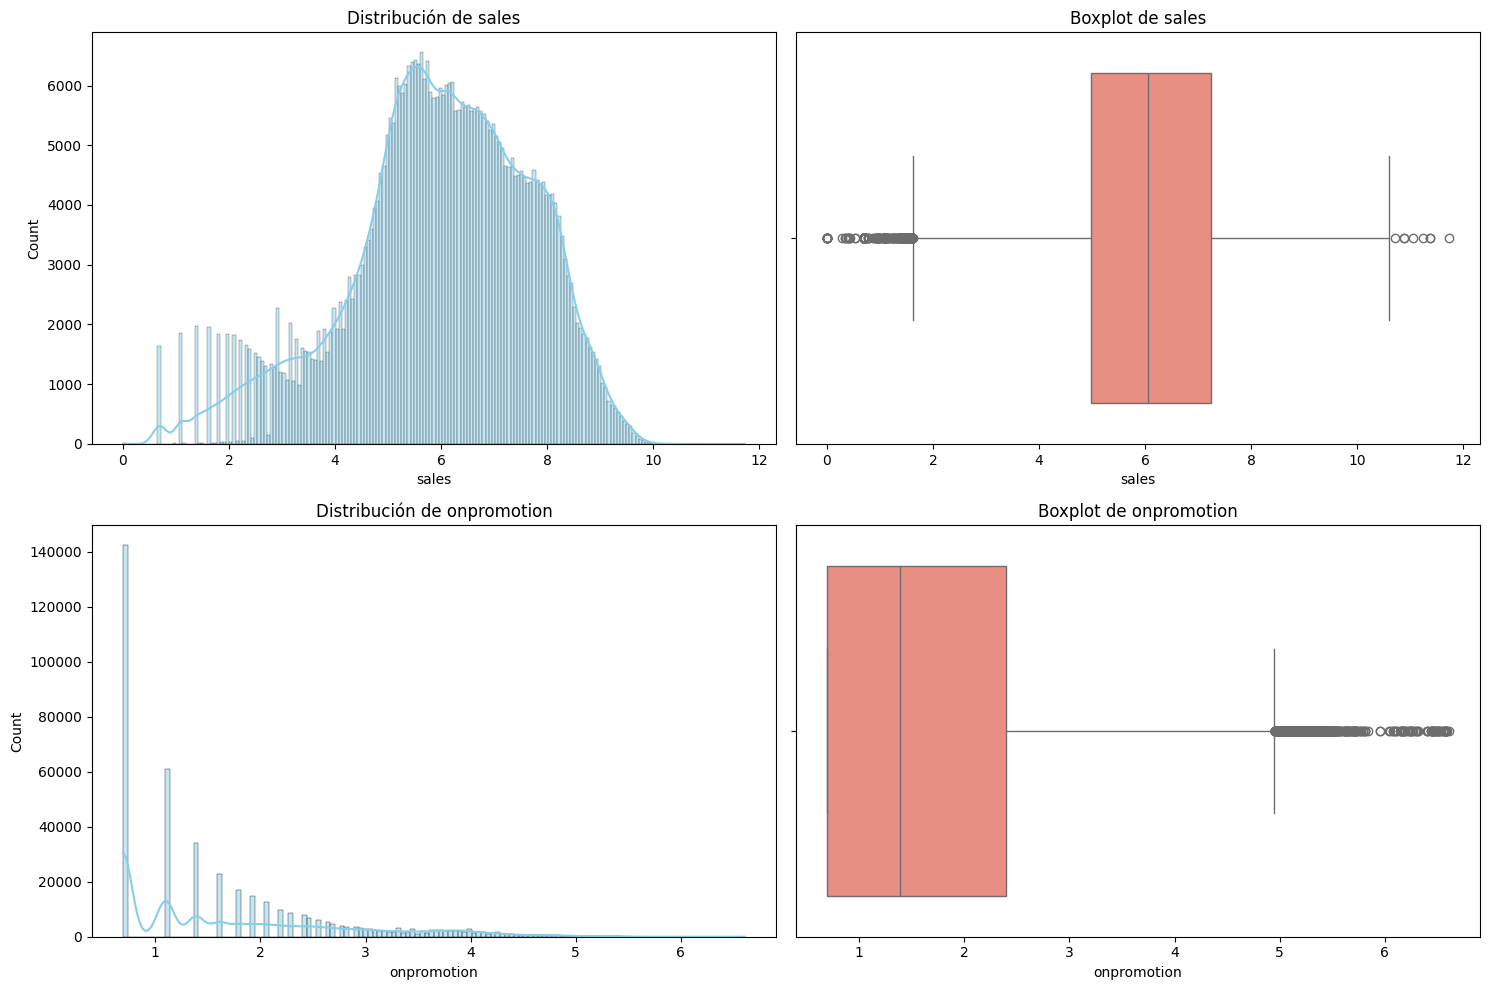

In [31]:
# 2. Definimos qué columnas queremos analizar (ejemplo: 'sales' y 'onpromotion')
columns_to_plot = ['sales', 'onpromotion'] 

# 3. Ajustamos la matriz de subplots según la cantidad de columnas
fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=2, figsize=(15, 10))

for i, col in enumerate(columns_to_plot):
    # Histograma (Columna 0 de la fila i)
    sns.histplot(df_promote[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribución de {col}')
    
    # Boxplot (Columna 1 de la fila i)
    sns.boxplot(x=df_promote[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

**Aplicamos Yeo Johnson a 'transactions' para comprobar si va a normalizar la distribución**

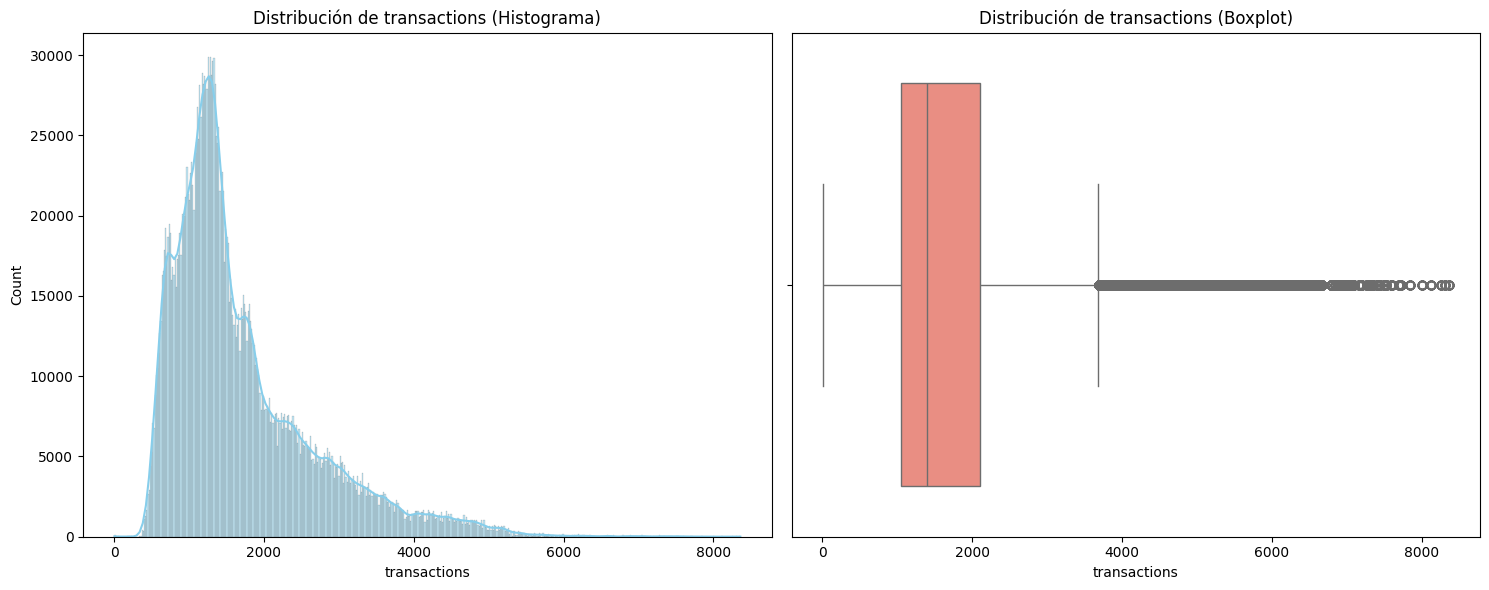

In [32]:
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_train['transactions'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de transactions (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_train['transactions'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de transactions (Boxplot)')

plt.tight_layout()
plt.show()

In [33]:
pt = PowerTransformer(method="yeo-johnson")
df_train['transactions_yj'] = pt.fit_transform(df_train[['transactions']])

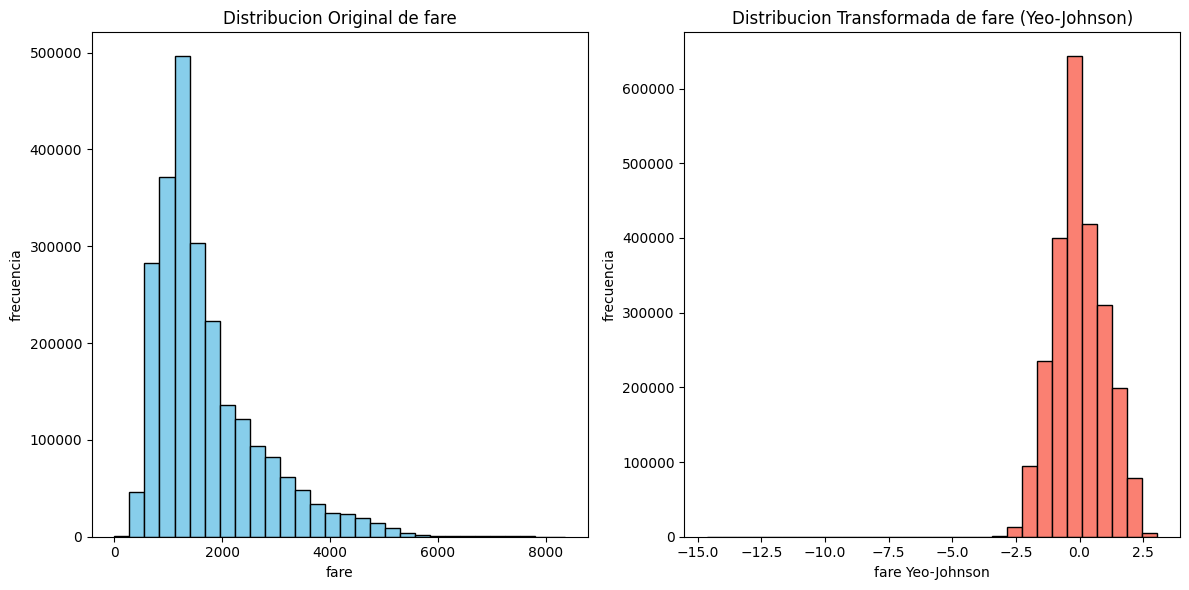

In [34]:
plt.figure(figsize=(12,6))

#histograma de la distribucion original de "fare"
plt.subplot(1,2,1)
plt.hist(df_train["transactions"],bins=30,color="skyblue",edgecolor="k")
plt.title("Distribucion Original de fare")
plt.xlabel("fare")
plt.ylabel("frecuencia")

#histograma de la distribucion transformada de "fare_yj"
plt.subplot(1,2,2)
plt.hist(df_train["transactions_yj"],bins=30,color="salmon",edgecolor="k")
plt.title("Distribucion Transformada de fare (Yeo-Johnson)")
plt.xlabel("fare Yeo-Johnson")
plt.ylabel("frecuencia")

plt.tight_layout()
plt.show()

Una vez aplicado el Yeo Johnson, podemos confirmar que sí que ha normalizado la distribución, vamos a comprobarlo con el histograma y el boxplot.

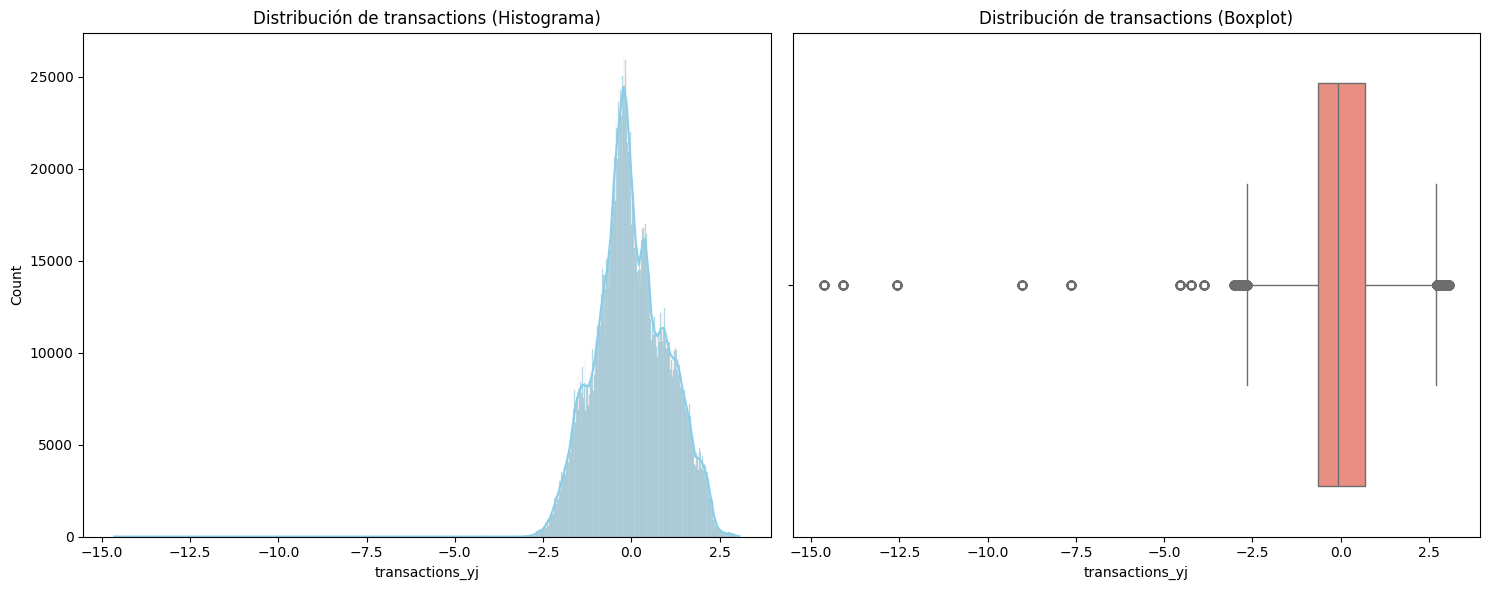

In [35]:
# Definimos 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# 1. Histograma - Se asigna al eje axes[0]
sns.histplot(df_train['transactions_yj'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de transactions (Histograma)')

# 2. Boxplot - Se asigna al eje axes[1]
sns.boxplot(x=df_train['transactions_yj'], color='salmon', ax=axes[1])
axes[1].set_title('Distribución de transactions (Boxplot)')

plt.tight_layout()
plt.show()

Vemos que si que ha surgido efecto, por lo que vamos a implementarlo en el Preprocessing.

**Cosas a implementar en el preprocessing!!!**

1. Aplicamos el logaritmo para 'onpromotion' y 'sales'
2. Aplicamos Yeo Johnson para 'transactions'

## **2. Columnas Categóricas**

<Figure size 1000x600 with 0 Axes>

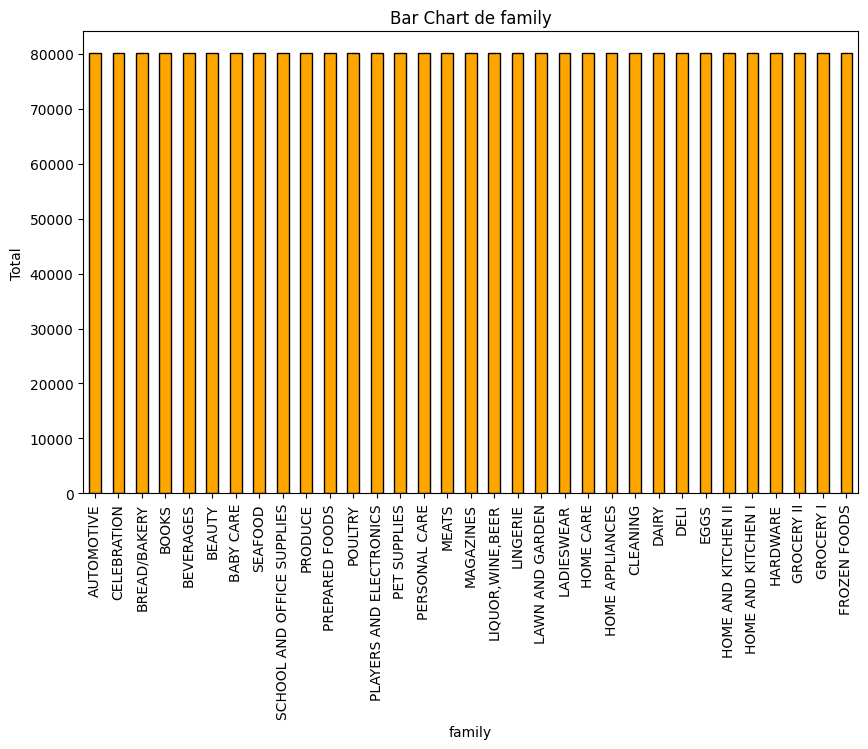

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

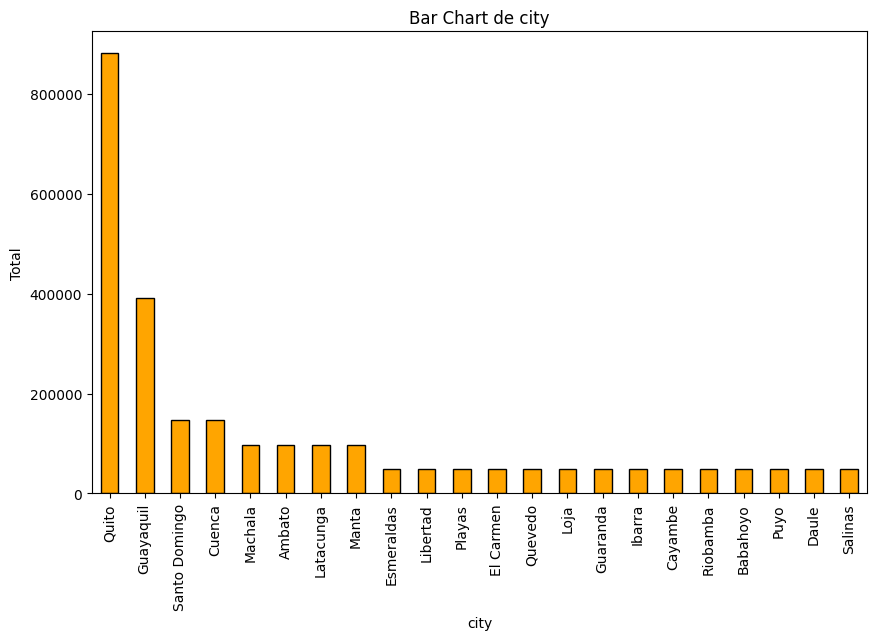

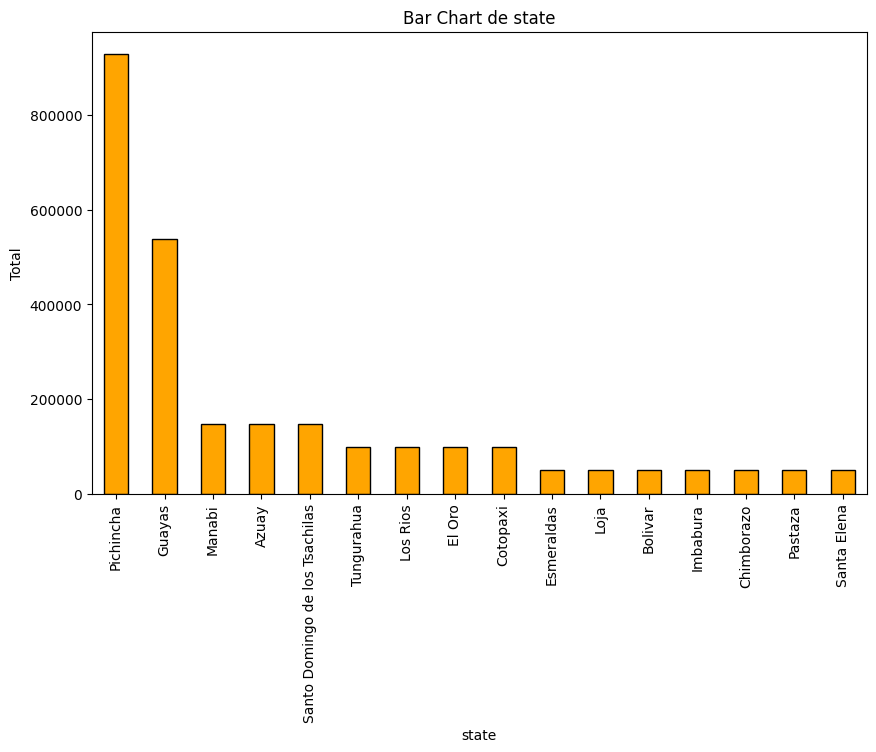

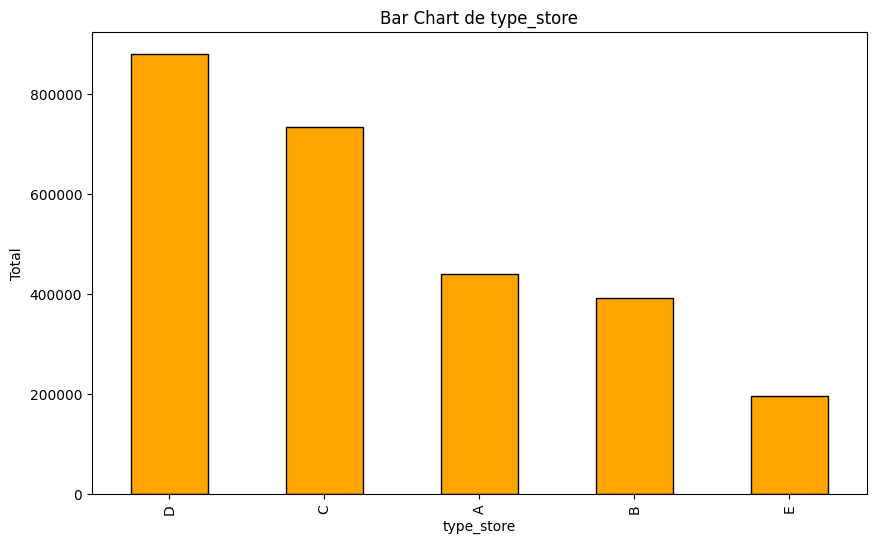

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

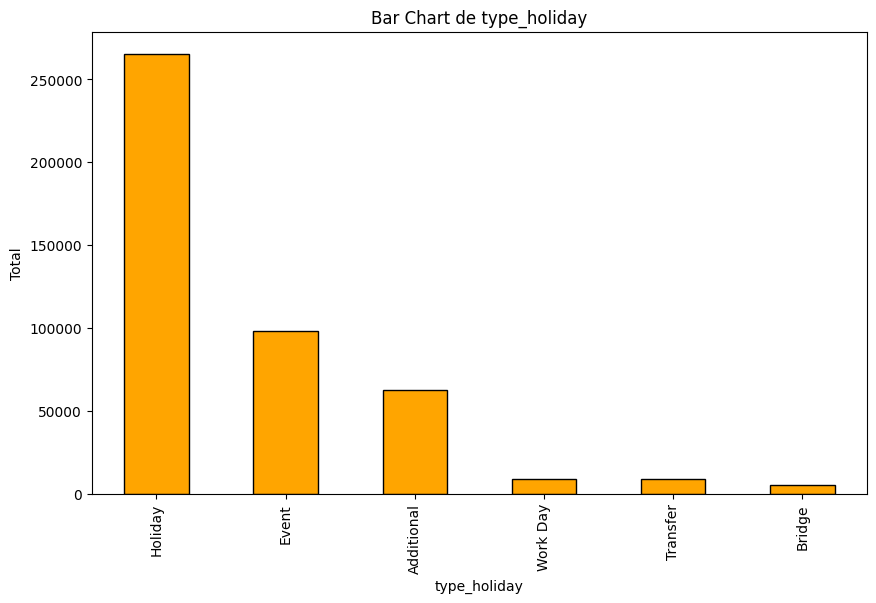

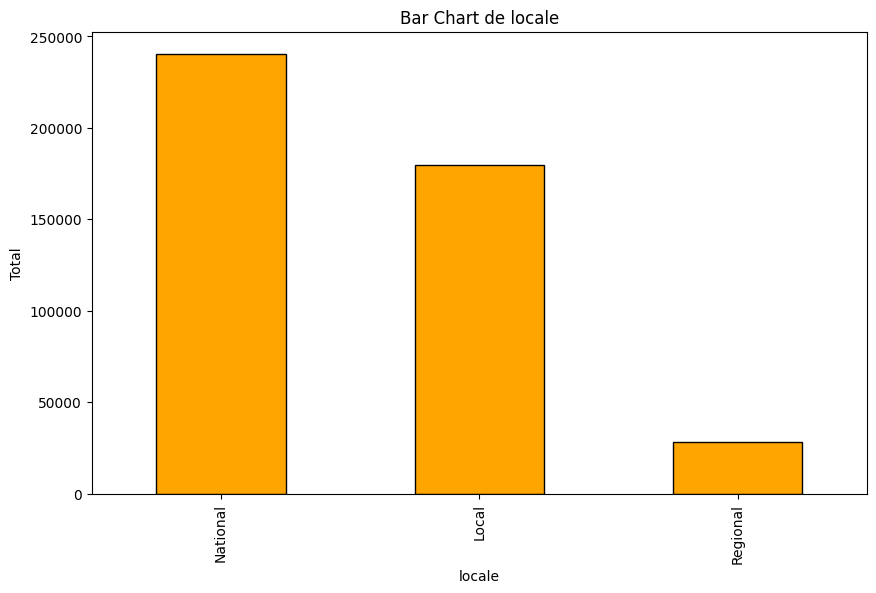

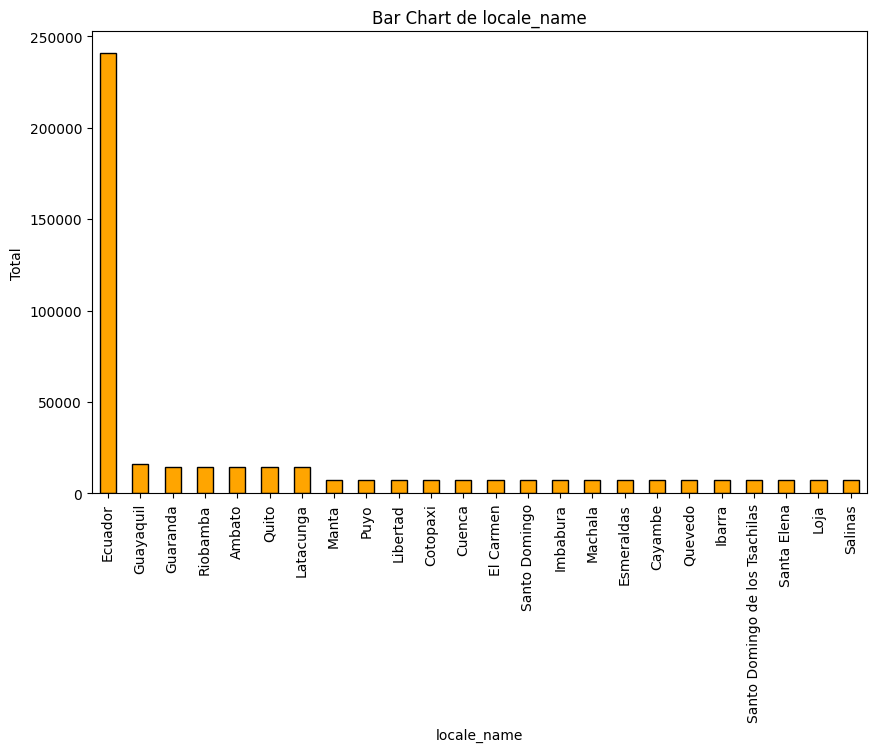

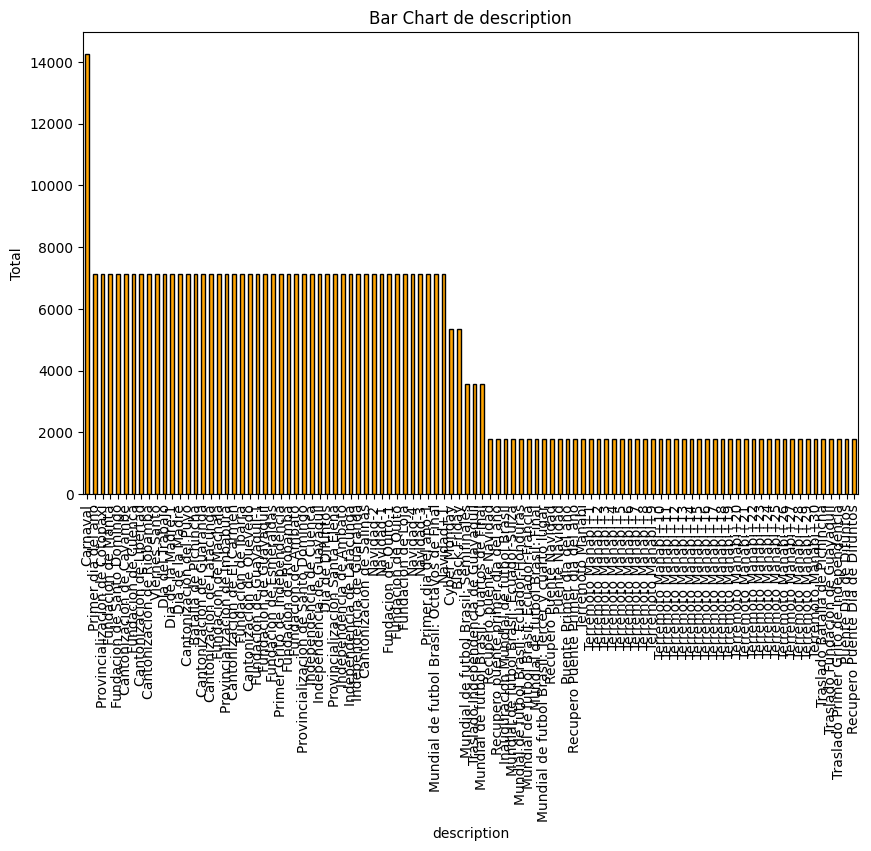

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [36]:
# Pintar la frecuencia por variable en gráfico de barras todas las columnas categóricas.
for column in df_train.columns:
    plt.figure(figsize=(10, 6))

    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        df_train[column].value_counts().plot(kind='bar', color='orange', edgecolor='black')
        plt.title(f'Bar Chart de {column}')
        plt.xlabel(column)
        plt.ylabel('Total')
    
    plt.show()

Observamos que la gran mayoría de las variables no tienen una cardinalidad alta, excepto para la variable 'description' (que no creemos que sea muy útil. Candidata a eliminar)

## **Análisis Bivariable**

Nuestra variable objetiva son las ventas ('sales'), por lo que vamos a realizar un Análisis Bivariable sobre cada una de las variables. Vamos a ver las siguientes gráficas:

**Variables Categóricas**

1. Ventas totales
2. Promedio de Ventas

**Variables Numéricas**

1. ScatterPlot
2. Es útil 'oil_price'?

**Variables Categóricas**

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


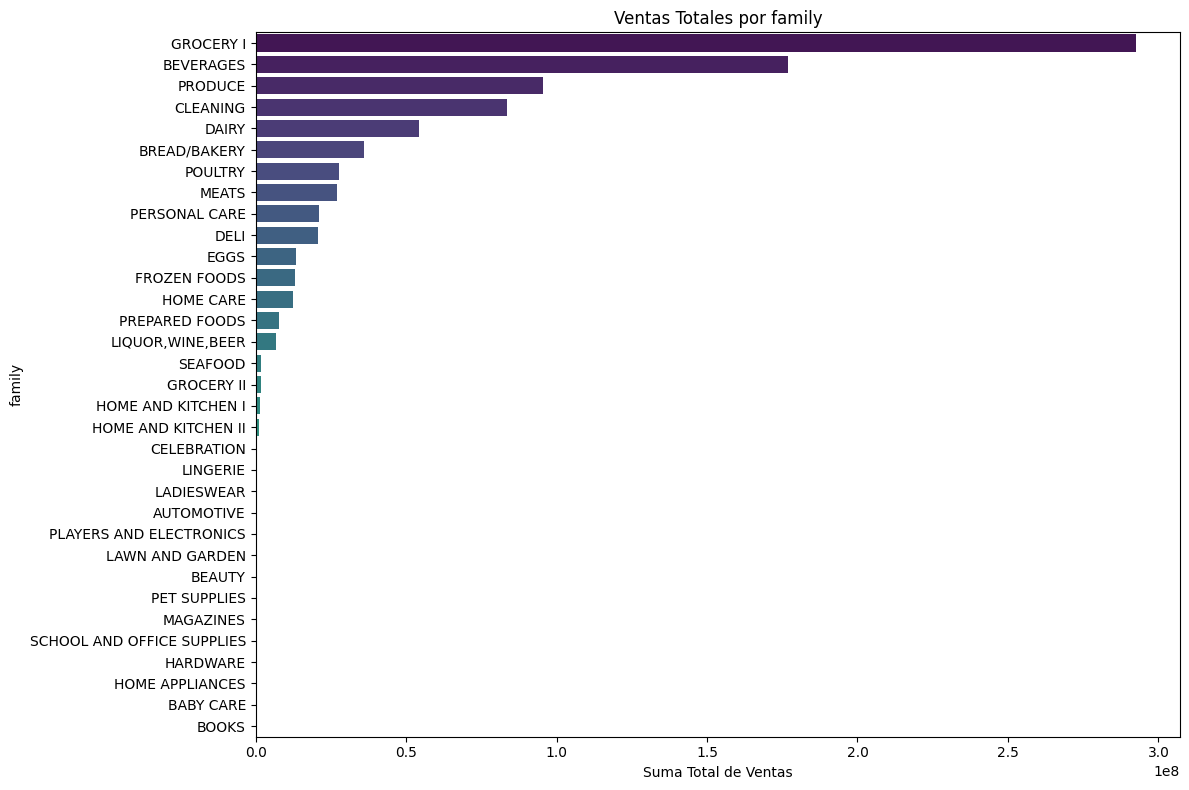

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


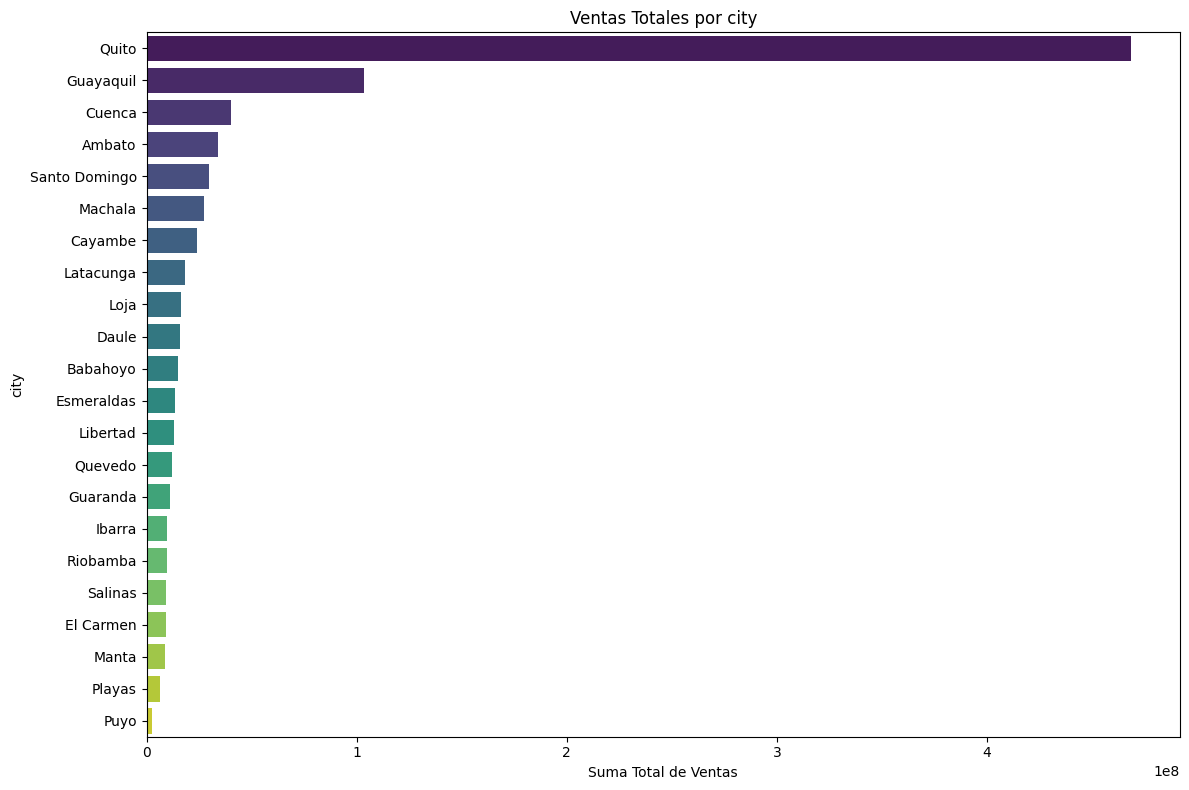

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


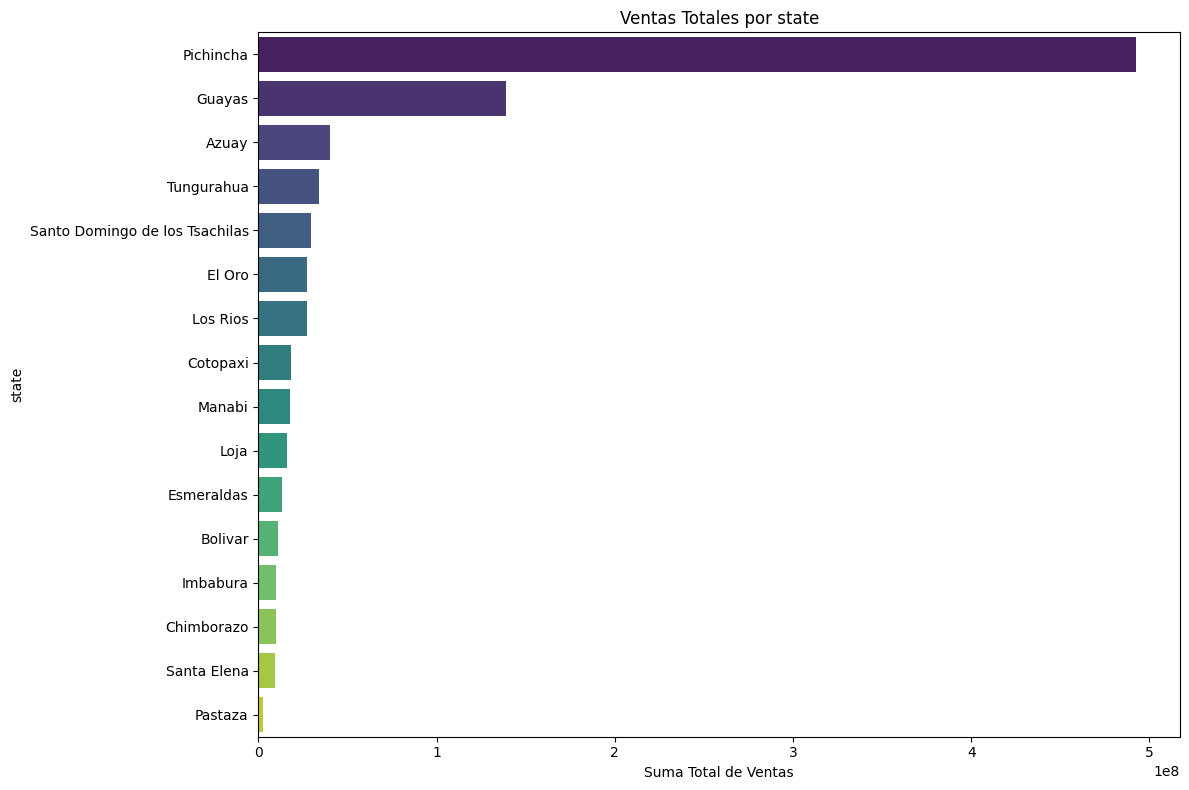

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


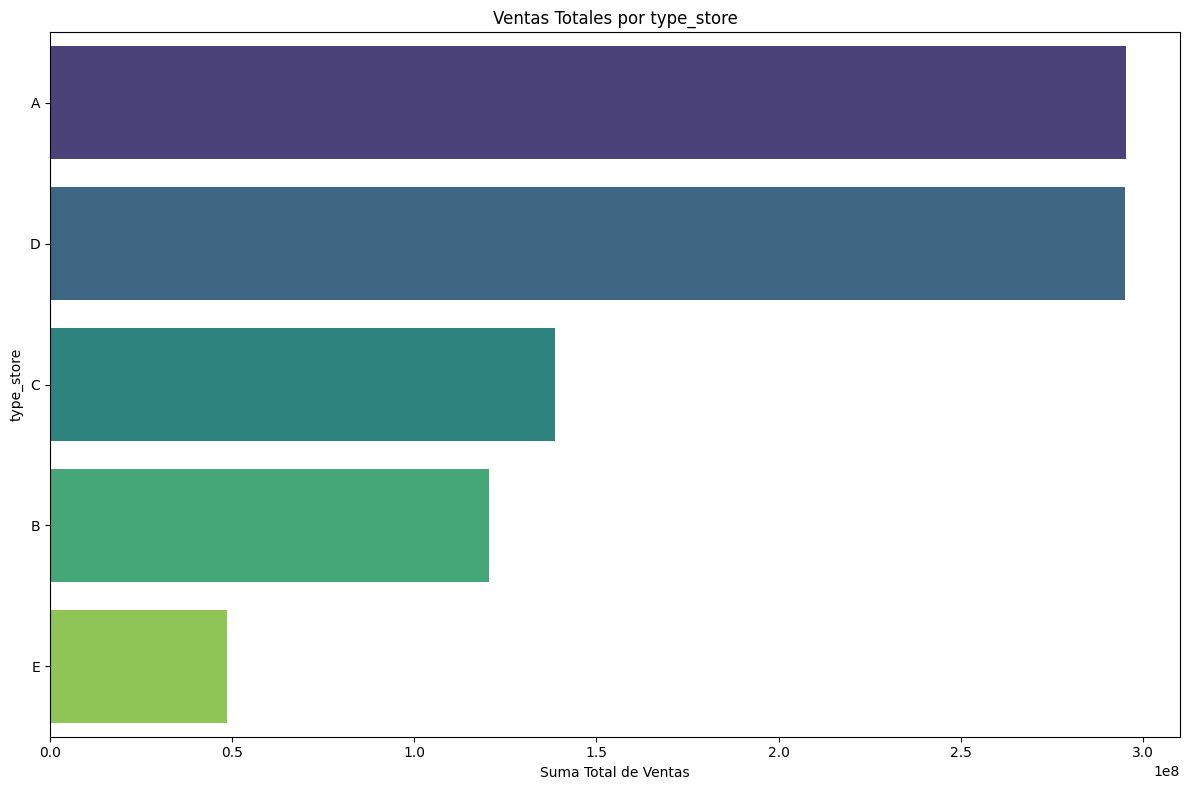

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


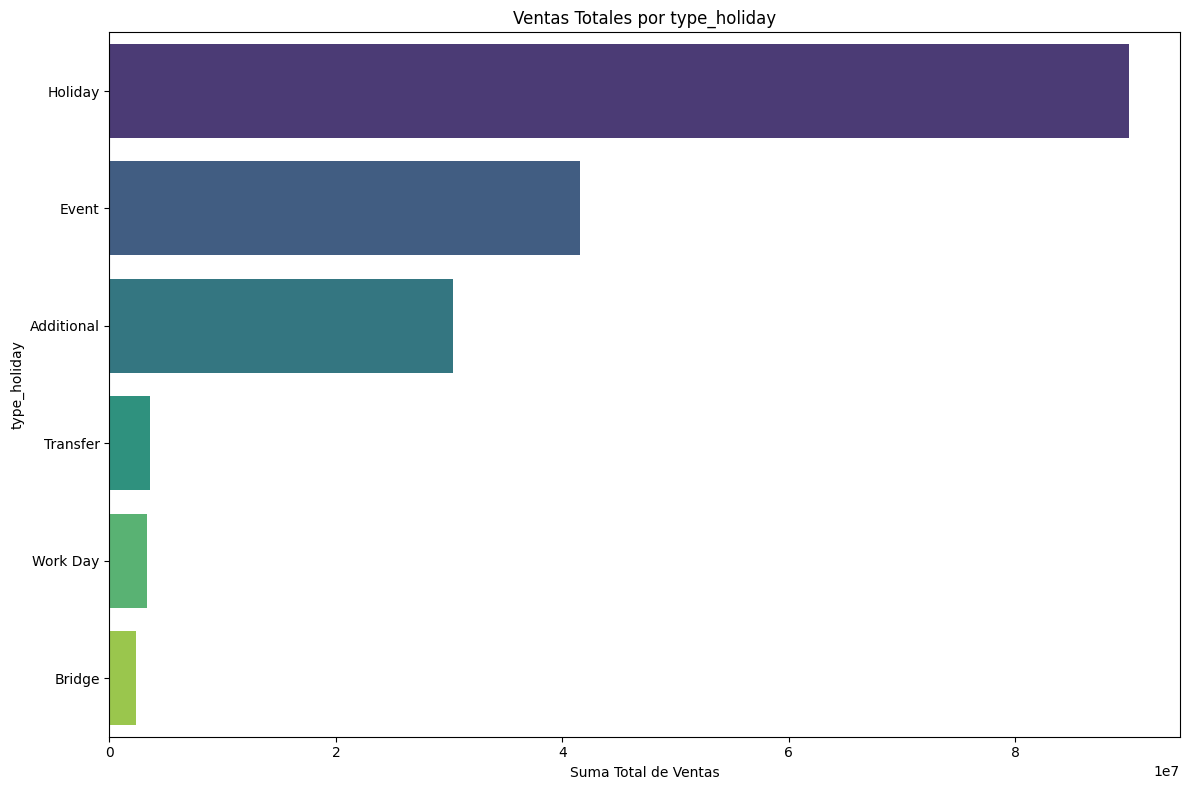

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


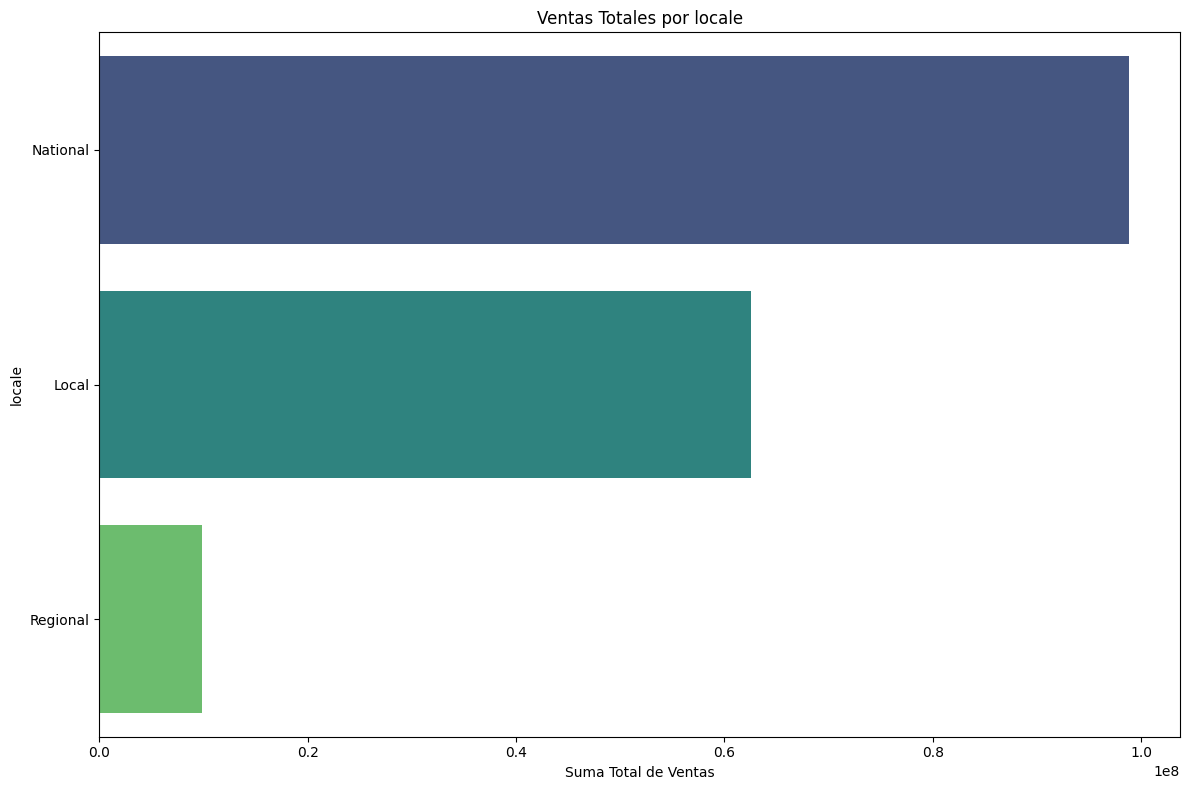

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


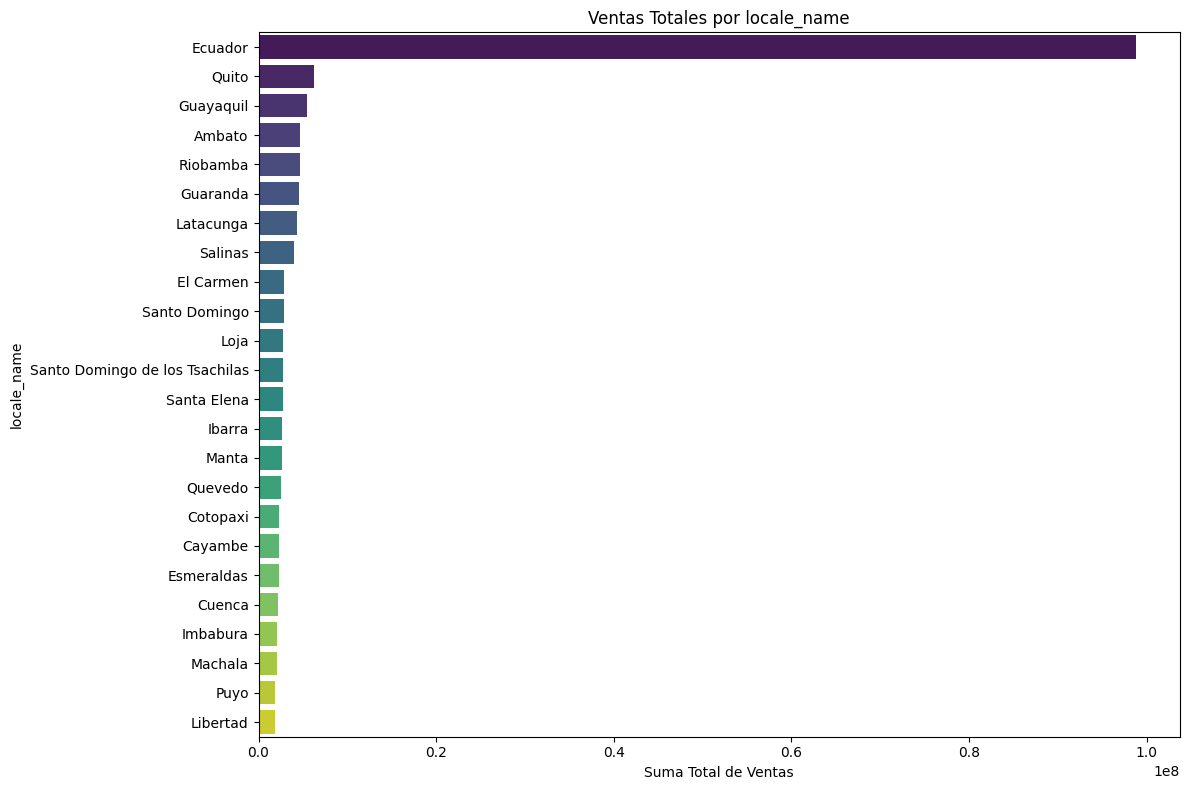

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


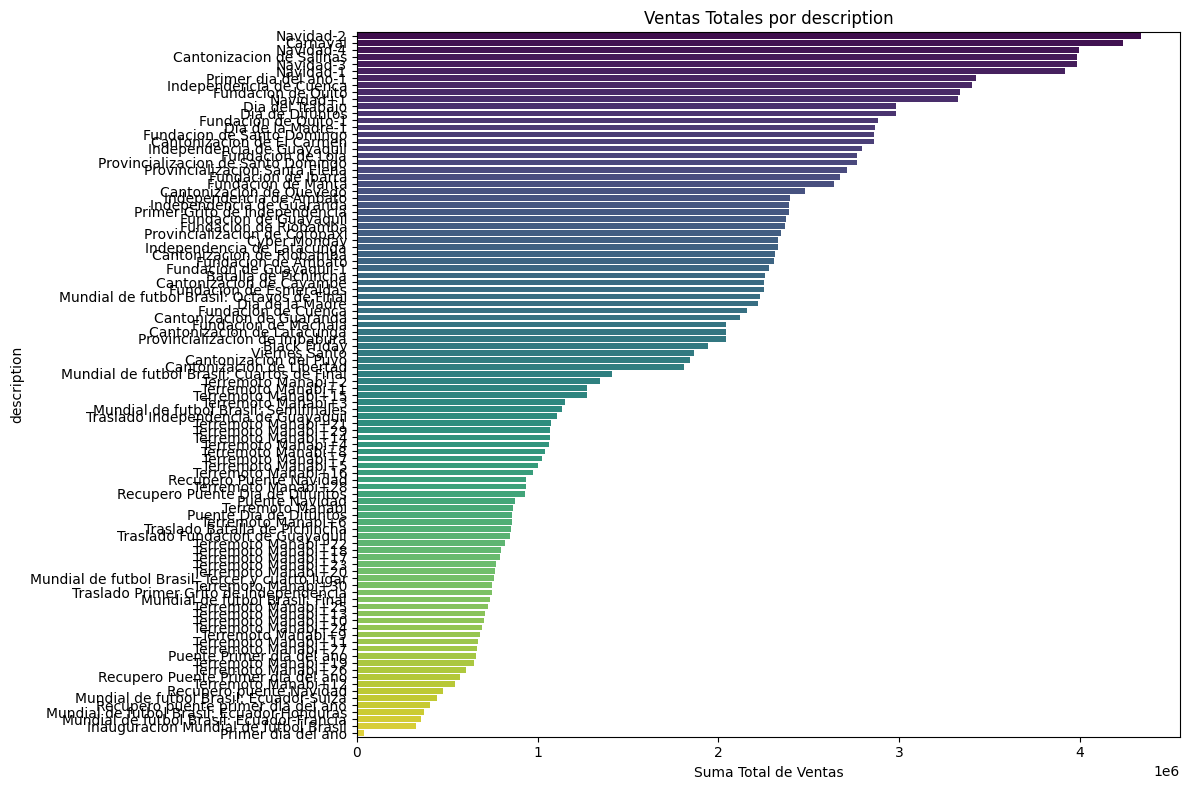

In [37]:
# Iteramos por todas las columnas del dataframe
for column in df_train.columns:
    
    # Comprobamos si la columna es categórica o tipo objeto
    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        
        plt.figure(figsize=(12, 8))
        
        # 1. Agrupamos y sumamos ventas (esto hace que el gráfico cargue rápido)
        df_grouped = df_train.groupby(column)['sales'].sum().sort_values(ascending=False).reset_index()
        
        # 2. Dibujamos el gráfico de barras
        # Usamos la columna actual en el eje Y y las ventas en el eje X
        sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')
        
        # 3. Títulos y etiquetas
        plt.title(f'Ventas Totales por {column}')
        plt.xlabel('Suma Total de Ventas')
        plt.ylabel(column)
        
        plt.tight_layout()
        plt.show()

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


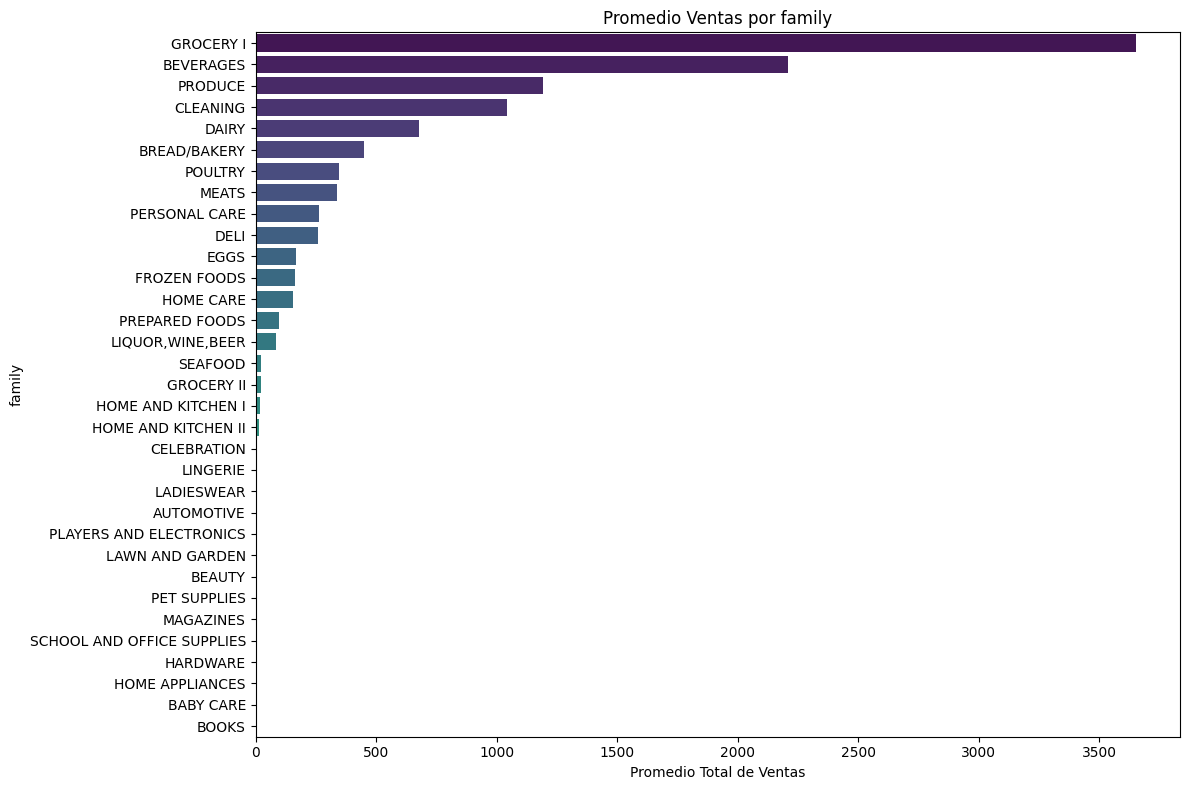

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


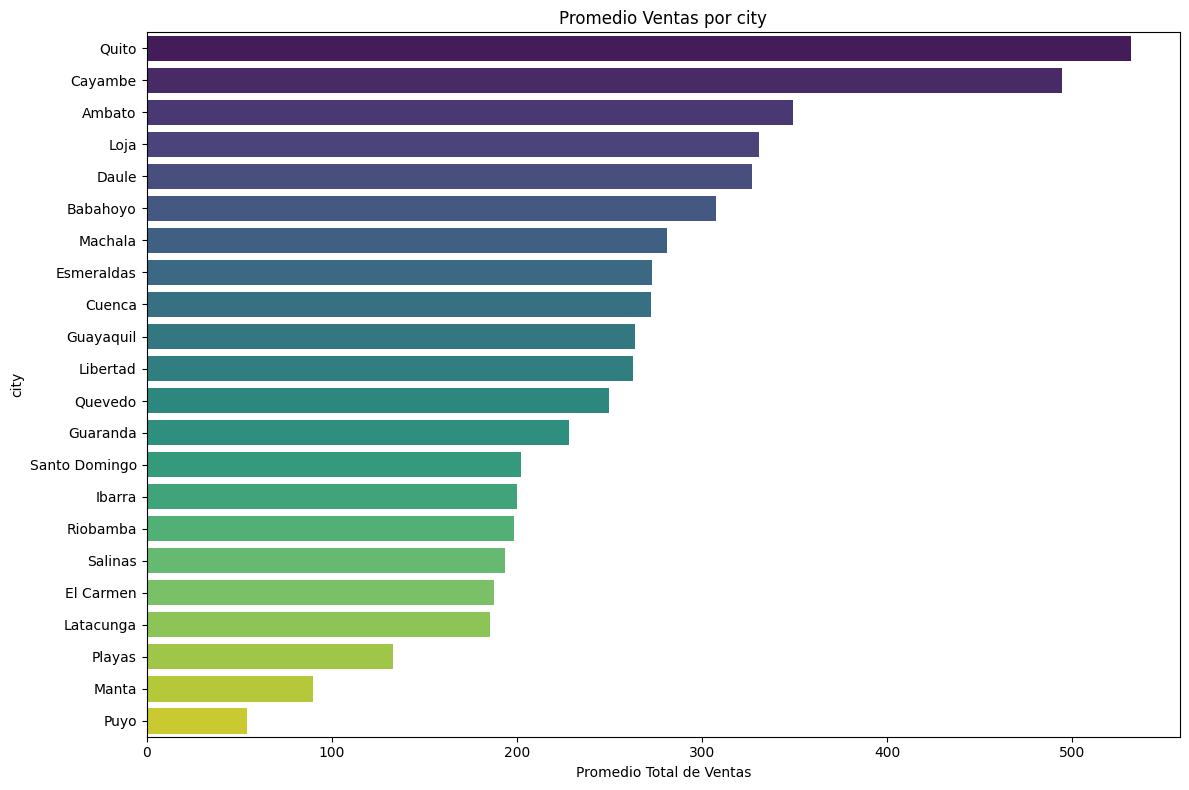

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


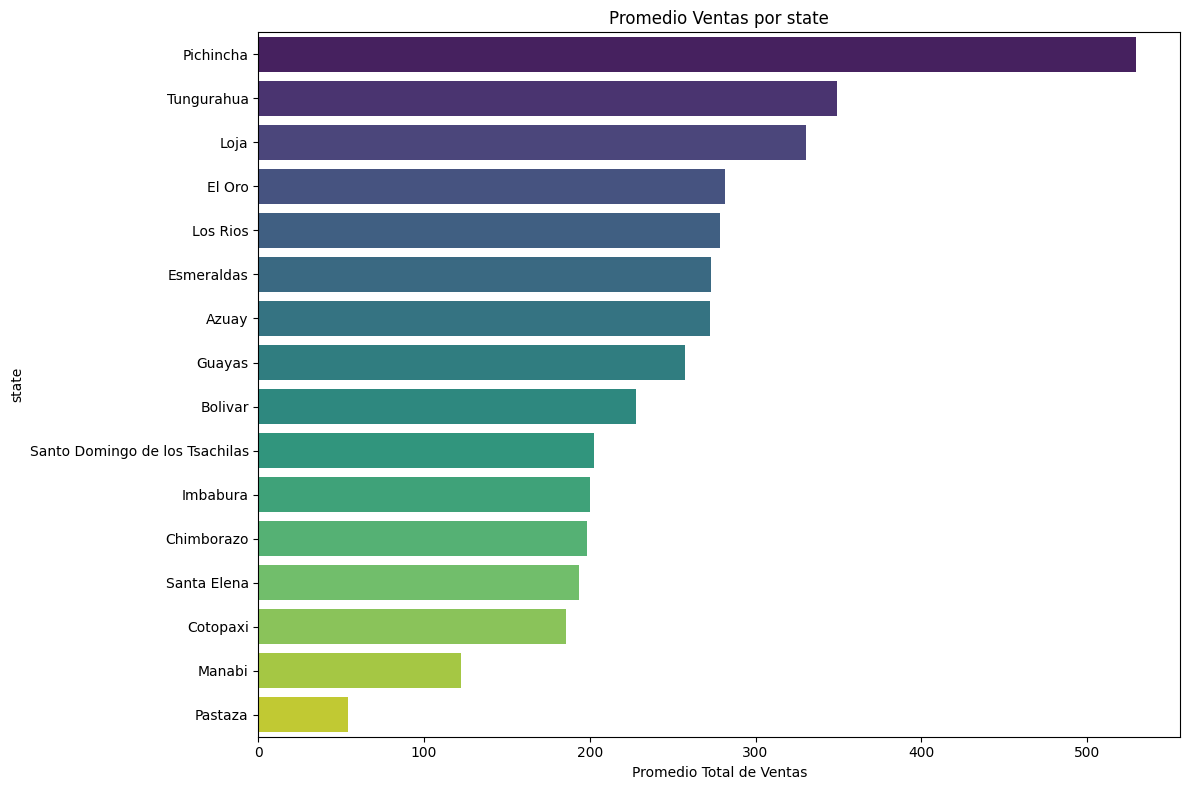

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


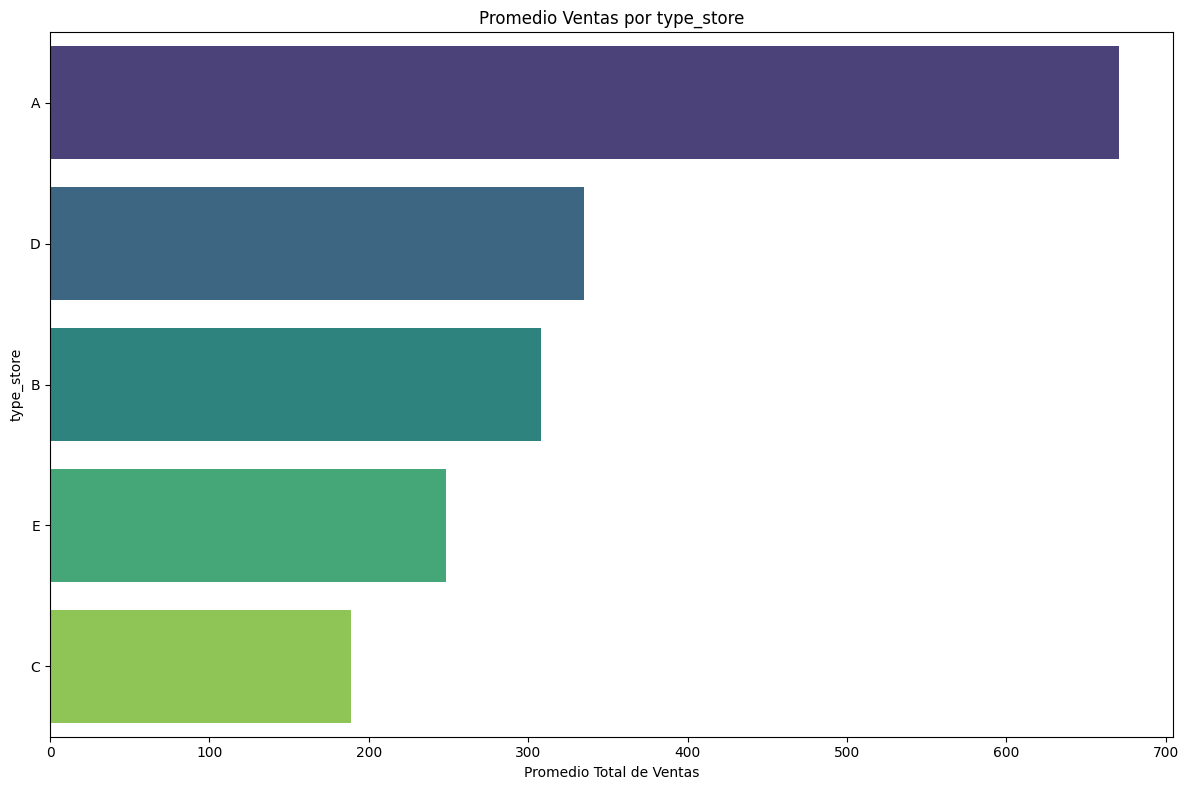

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


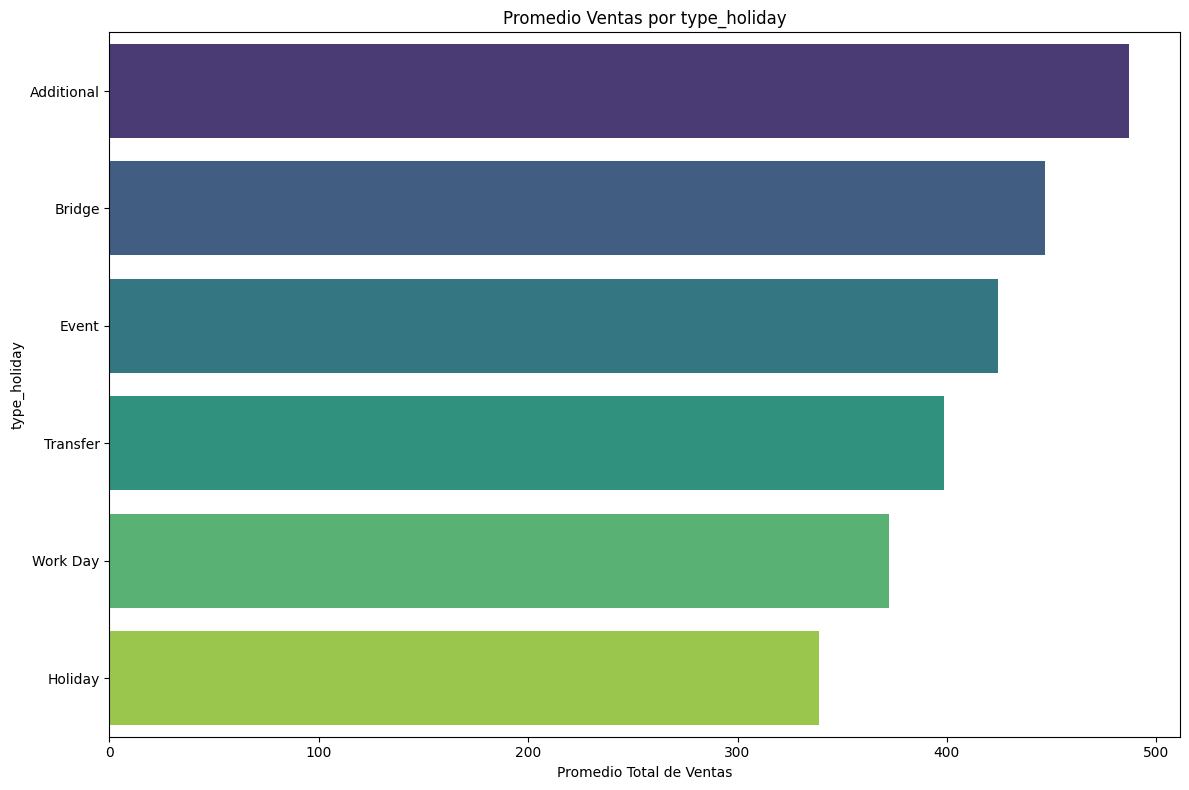

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


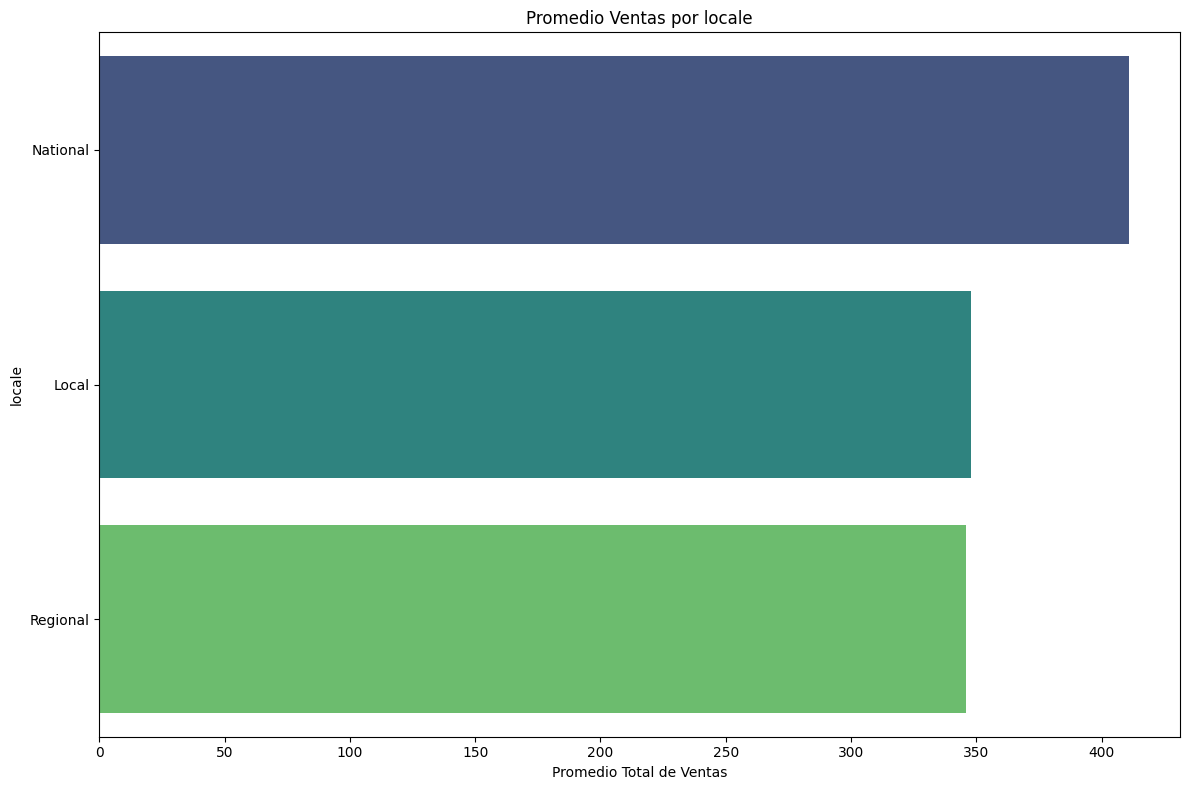

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


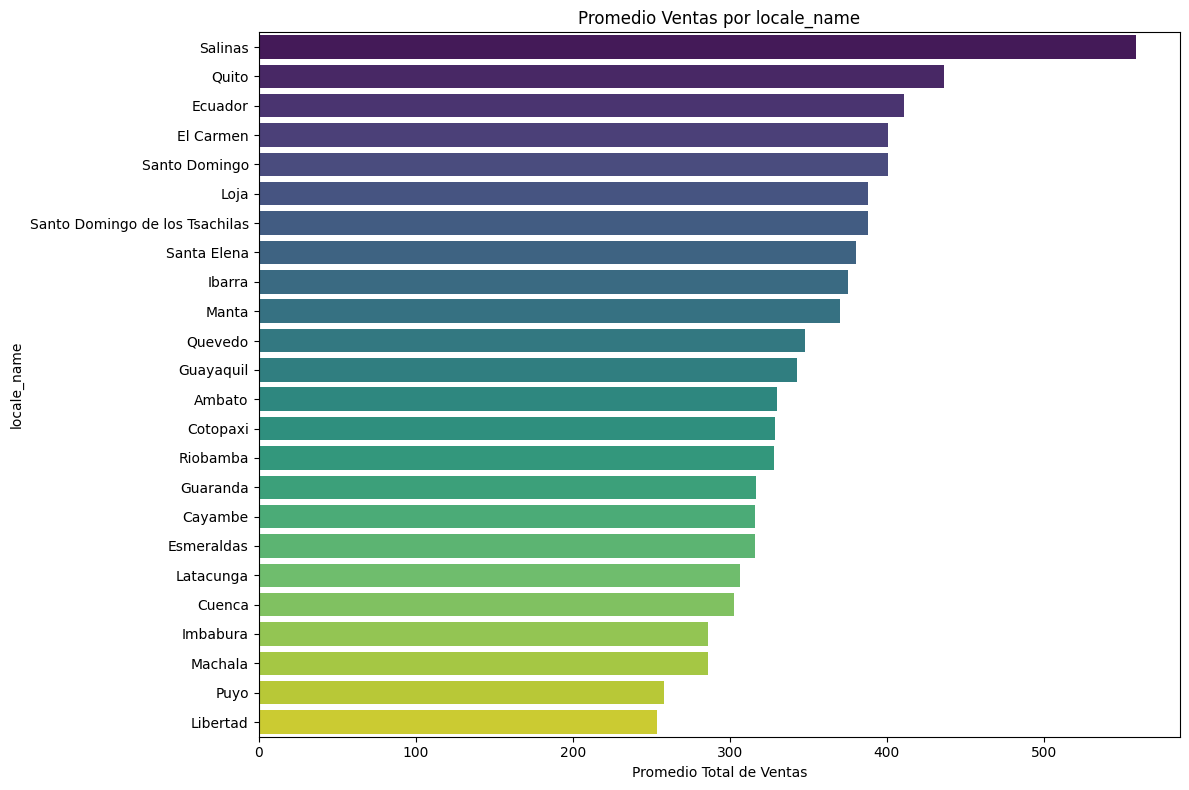

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_17044\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


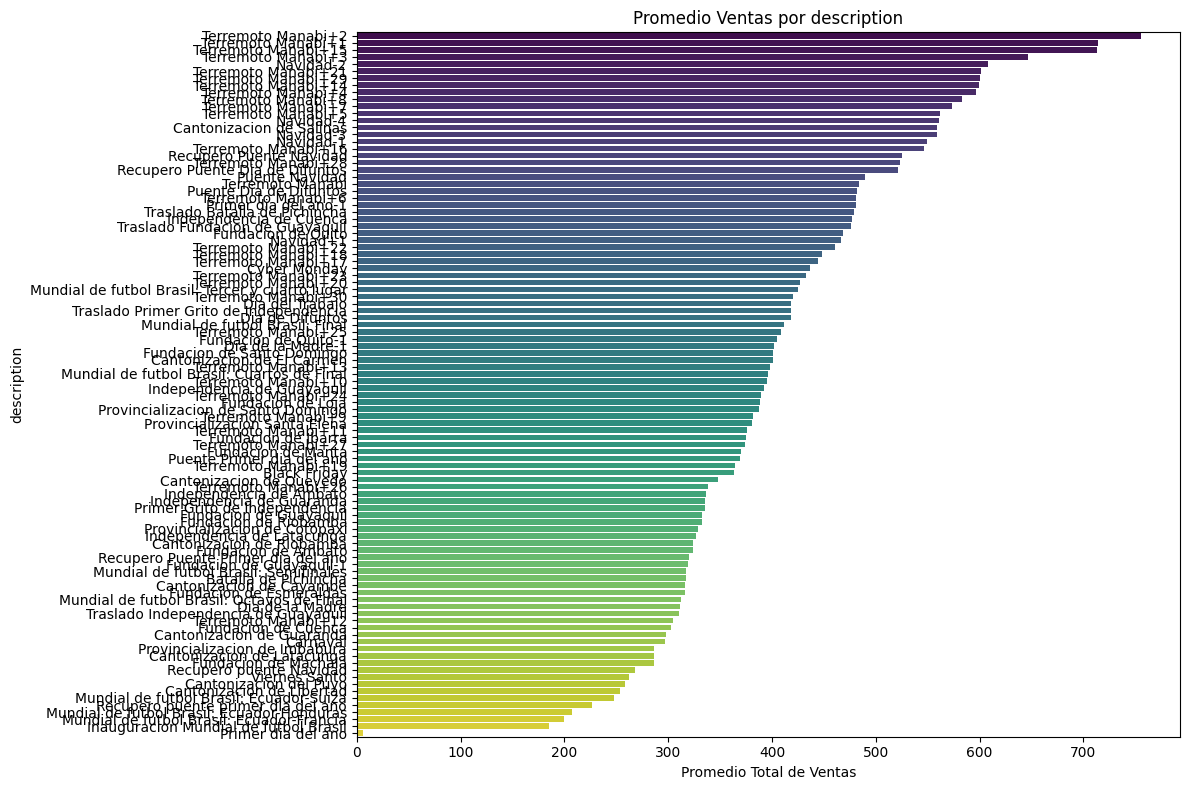

In [38]:
# Iteramos por todas las columnas del dataframe
for column in df_train.columns:
    
    # Comprobamos si la columna es categórica o tipo objeto
    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        
        plt.figure(figsize=(12, 8))
        
        # 1. Agrupamos y sumamos ventas (esto hace que el gráfico cargue rápido)
        df_grouped = df_train.groupby(column)['sales'].mean().sort_values(ascending=False).reset_index()
        
        # 2. Dibujamos el gráfico de barras
        # Usamos la columna actual en el eje Y y las ventas en el eje X
        sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')
        
        # 3. Títulos y etiquetas
        plt.title(f'Promedio Ventas por {column}')
        plt.xlabel('Promedio Total de Ventas')
        plt.ylabel(column)
        
        plt.tight_layout()
        plt.show()

**Variables numéricas**

In [39]:
df_train[numeric_cols].dtypes

sales           float64
onpromotion       int64
cluster           int64
transactions    float64
oil_price       float64
dtype: object

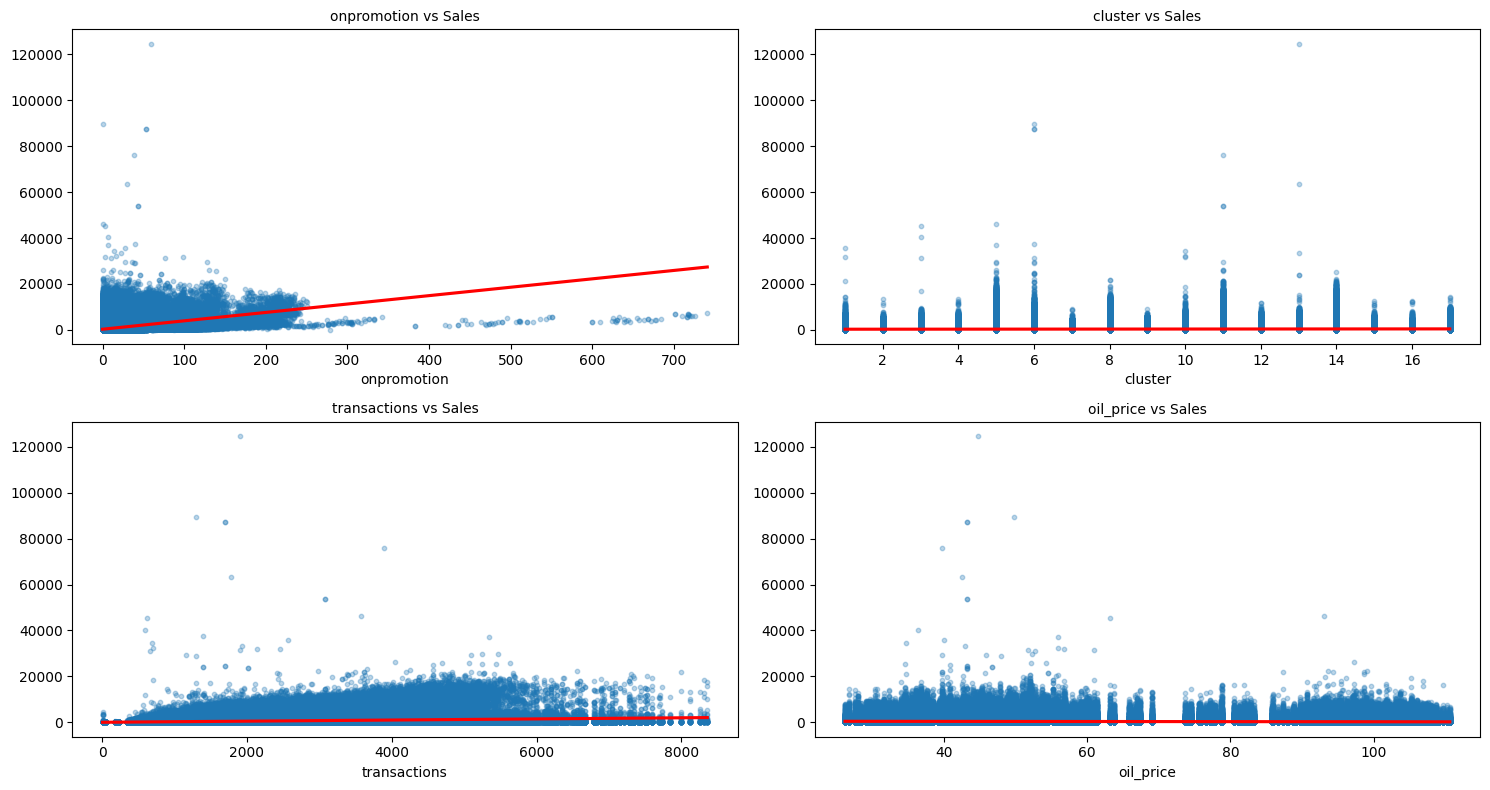

In [40]:
# 1. Filtro rápido: eliminamos 'sales' si está en la lista
cols_to_plot = [c for c in numeric_cols if c != 'sales']

n_rows = (len(cols_to_plot) + 1) // 2
fig, axs = plt.subplots(n_rows, 2, figsize=(15, 4 * n_rows))
axs = axs.flatten()

for i, col in enumerate(cols_to_plot):
    # ci=None: Desactiva el intervalo de confianza (esto ahorra el 90% del tiempo)
    # sample: Si tienes >100k filas, podrías usar data=df_train.sample(10000)
    sns.regplot(data=df_train, x=col, y='sales', ax=axs[i], 
                ci=None, 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'})
    
    axs[i].set_title(f'{col} vs Sales', fontsize=10)
    axs[i].set_ylabel('') # Menos texto, más limpio

# Limpieza de ejes vacíos
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

**Cómo influyen las fechas a la target?** 

Vamos a separarlo en año, mes, dia, y dias de la semana.

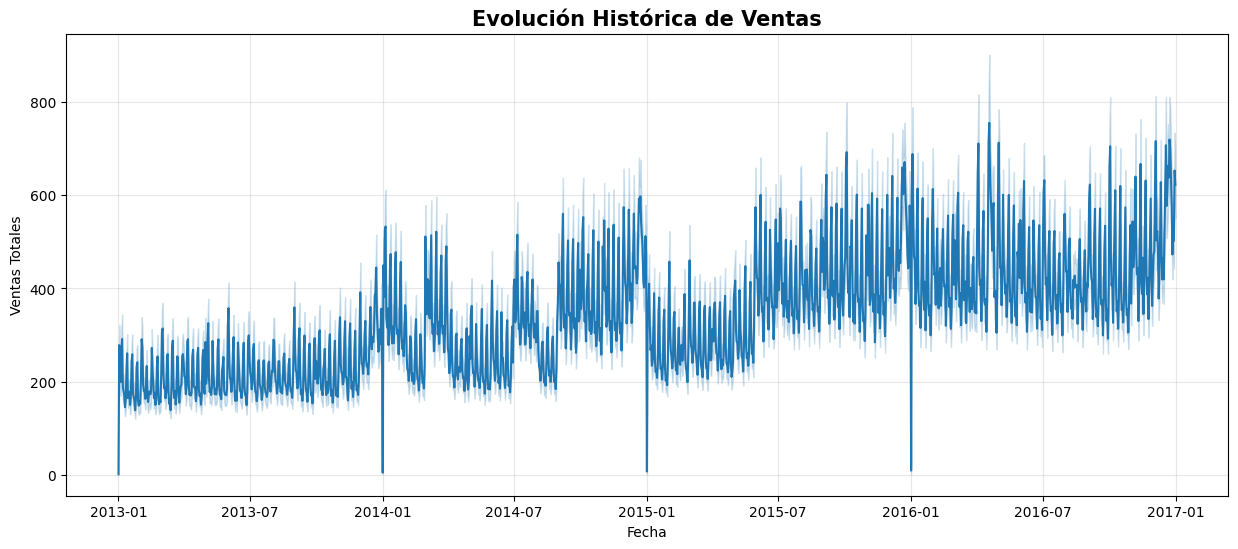

In [42]:
#GRÁFICOS PARA VER ESTACIONALIDAD
plt.figure(figsize=(15, 6))

# Gráfico de línea
sns.lineplot(data=df_train, x='date', y='sales')

plt.title('Evolución Histórica de Ventas', fontsize=15, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True, alpha=0.3)
plt.show()

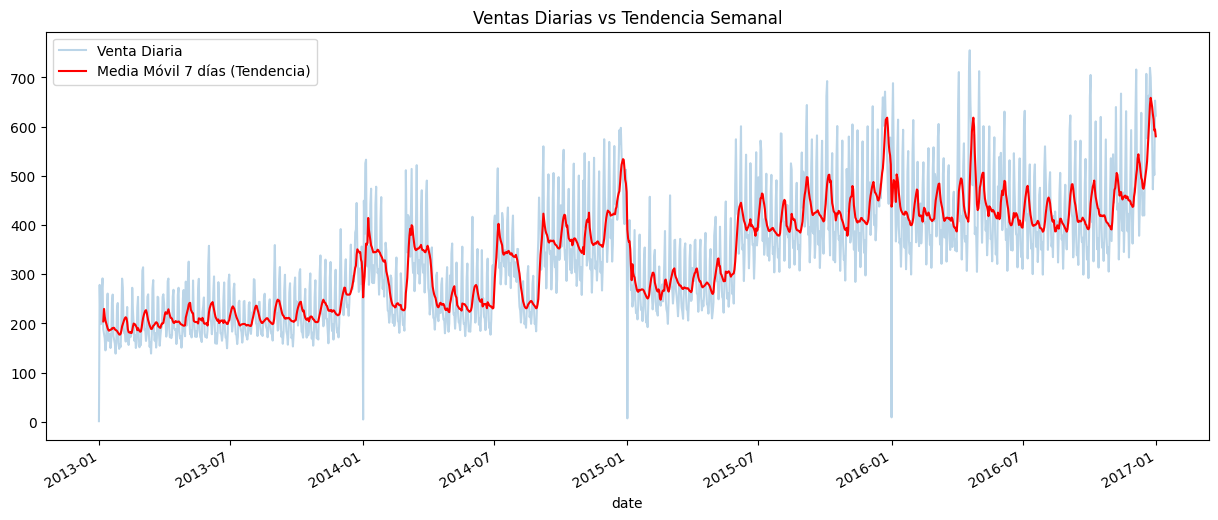

In [43]:
# Creamos una serie temporal agrupada por día (promedio de todas las tiendas/productos)
daily_sales = df_train.groupby('date')['sales'].mean()

plt.figure(figsize=(15, 6))
daily_sales.plot(alpha=0.3, label='Venta Diaria')
daily_sales.rolling(window=7).mean().plot(color='red', label='Media Móvil 7 días (Tendencia)')

plt.title('Ventas Diarias vs Tendencia Semanal')
plt.legend()
plt.show()

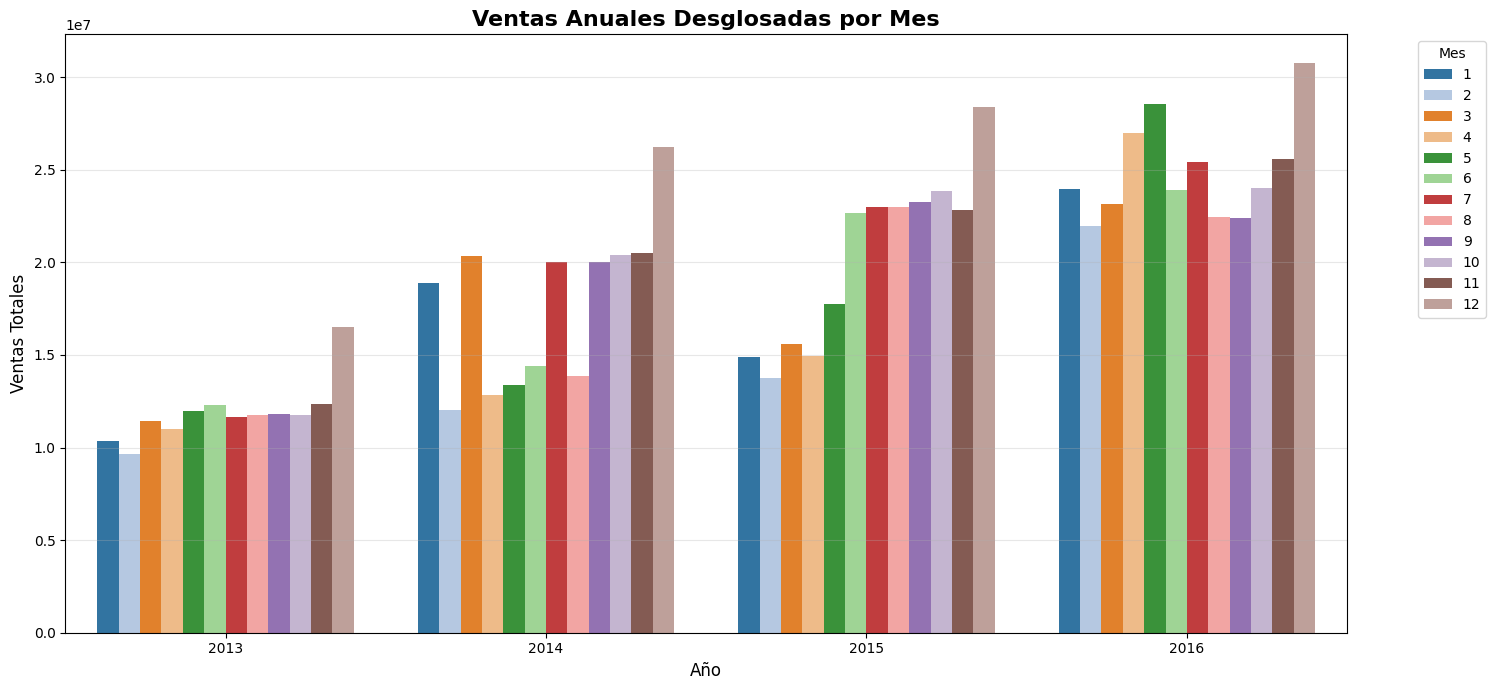

In [44]:
# 1. Aseguramos que las columnas existan
df_train['year'] = df_train['date'].dt.year
df_train['month'] = df_train['date'].dt.month

# 2. Agrupamos por Año y Mes
monthly_sales = df_train.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(15, 7))

# 3. Graficamos: X es el año, el color (hue) es el mes
sns.barplot(data=monthly_sales, x='year', y='sales', hue='month', palette='tab20')

# Ajustes estéticos
plt.title('Ventas Anuales Desglosadas por Mes', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas Totales', fontsize=12)

# Movemos la leyenda fuera del gráfico para que no estorbe
plt.legend(title='Mes', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

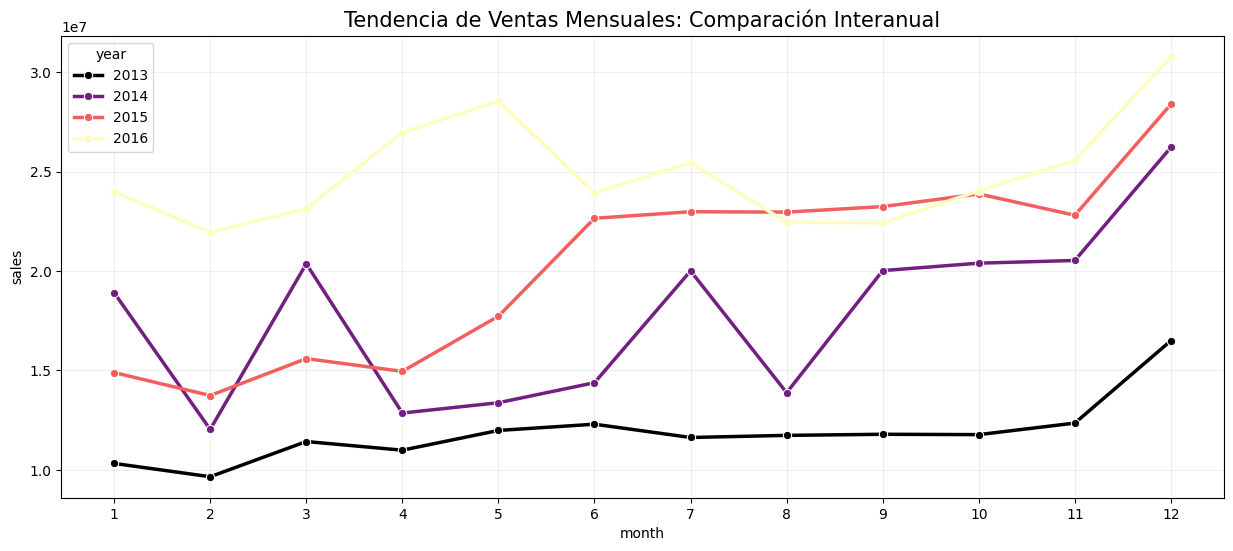

In [45]:
plt.figure(figsize=(15, 6))

# Usamos lineplot con hue='year'
sns.lineplot(data=monthly_sales, x='month', y='sales', hue='year', 
             marker='o', palette='magma', linewidth=2.5)

plt.xticks(range(1, 13)) # Asegura que salgan los 12 meses
plt.title('Tendencia de Ventas Mensuales: Comparación Interanual', fontsize=15)
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# 1. Agrupamos por Año y Mes
# (Asegúrate de haber ejecutado df_train['month'] = df_train['date'].dt.month)
sales_year_month = df_train.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_year_month, x='month', y='sales', hue='year', 
             marker='o', palette='viridis', linewidth=2.5)

plt.title('Comparativa de Ventas Mensuales entre Años', fontsize=15)
plt.xticks(range(1, 13)) # Forzamos que salgan los 12 meses
plt.grid(True, alpha=0.3)
plt.legend(title='Año')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

# El boxplot nos dirá si el "grueso" de las ventas ha subido año tras año
sns.boxplot(data=df_train, x='year', y='sales', palette='magma')

plt.title('Distribución de Ventas Diarias por Año', fontsize=15)
plt.ylabel('Ventas')
plt.xlabel('Año')
plt.show()

me falta por dias

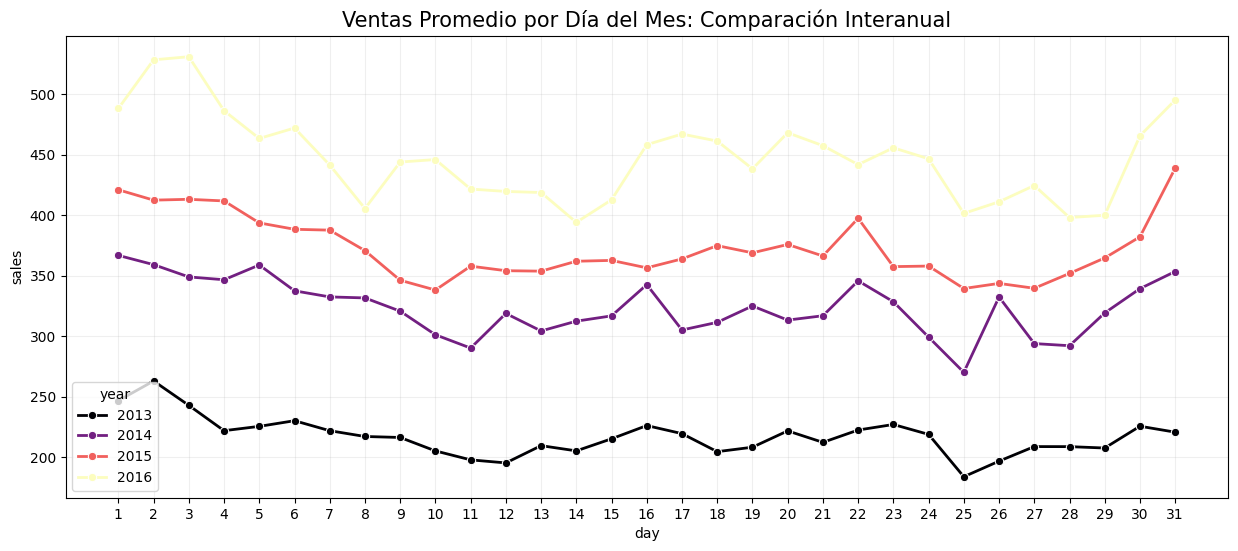

In [47]:
# 1. Agrupamos por Año y Día para tener el promedio de ventas de ese día
daily_sales_agg = df_train.groupby(['year', 'day'])['sales'].mean().reset_index()

plt.figure(figsize=(15, 6))

# 2. Graficamos
sns.lineplot(data=daily_sales_agg, x='day', y='sales', hue='year', 
             marker='o', palette='magma', linewidth=2)

# Ajustamos el eje X para que muestre los 31 días
plt.xticks(range(1, 32)) 
plt.title('Ventas Promedio por Día del Mes: Comparación Interanual', fontsize=15)
plt.grid(True, alpha=0.2)
plt.show()

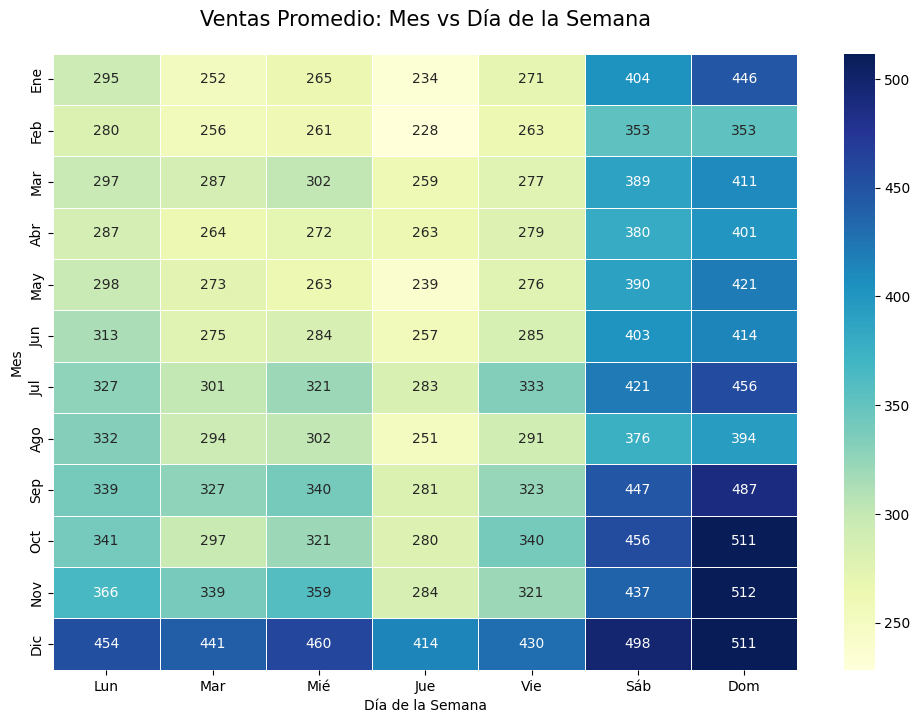

In [ ]:

df_train['month'] = df_train['date'].dt.month
df_train['day_of_week'] = df_train['date'].dt.dayofweek # 0=Lunes, 6=Domingo

# 2. Agrupar y pivotar
# Calculamos la media de ventas para cada combinación de Mes y Día
heatmap_data = df_train.groupby(['month', 'day_of_week'])['sales'].mean().unstack()

# 3. Renombrar ejes para que sea legible
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
heatmap_data.columns = dias
heatmap_data.index = meses

# 4. Dibujar el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True,       # Muestra los números dentro de las celdas
            fmt=".0f",        # Formato sin decimales
            cmap="YlGnBu",    # Escala de colores (Amarillo -> Verde -> Azul)
            linewidths=.5)    # Espacio entre celdas

plt.title('Ventas Promedio: Mes vs Día de la Semana', fontsize=15, pad=20)
plt.xlabel('Día de la Semana')
plt.ylabel('Mes')
plt.show()

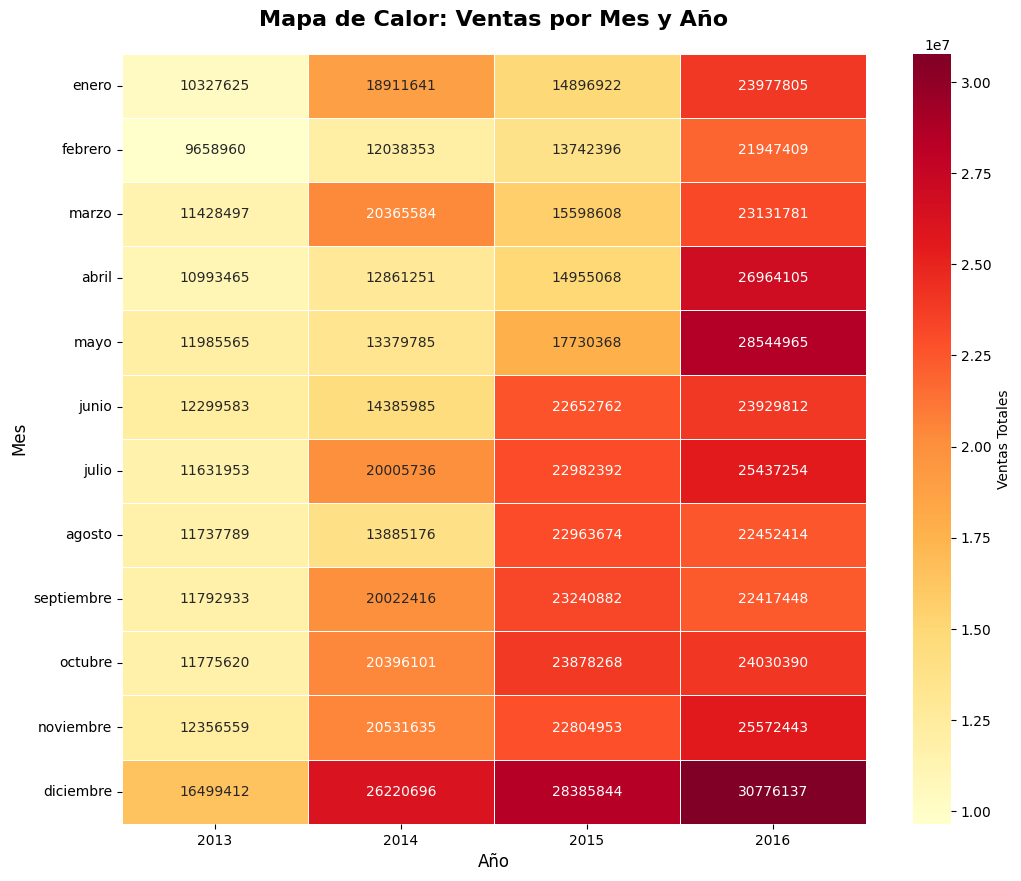

In [ ]:
# 1. Preparar las columnas de tiempo
df_train['year'] = df_train['date'].dt.year
df_train['month'] = df_train['date'].dt.month

# 2. Pivotar los datos: Meses en filas, Años en columnas, Ventas como valor
# Usamos 'mean' o 'sum' según prefieras ver el promedio mensual o el total
heatmap_data = df_train.pivot_table(index='month', columns='year', values='sales', aggfunc='sum')

# 3. Cambiar números de meses por nombres para mejor lectura
heatmap_data.index = [calendar.month_name[m] for m in heatmap_data.index]

# 4. Crear el Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            annot=True,              # Mostrar los valores
            fmt=".0f",               # Sin decimales
            cmap="YlOrRd",           # Escala: Amarillo (bajo) -> Naranja -> Rojo (alto)
            linewidths=.5,           # Línea divisoria entre celdas
            cbar_kws={'label': 'Ventas Totales'})

plt.title('Mapa de Calor: Ventas por Mes y Año', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Mes', fontsize=12)
plt.show()

El precio de la gasolina influye?

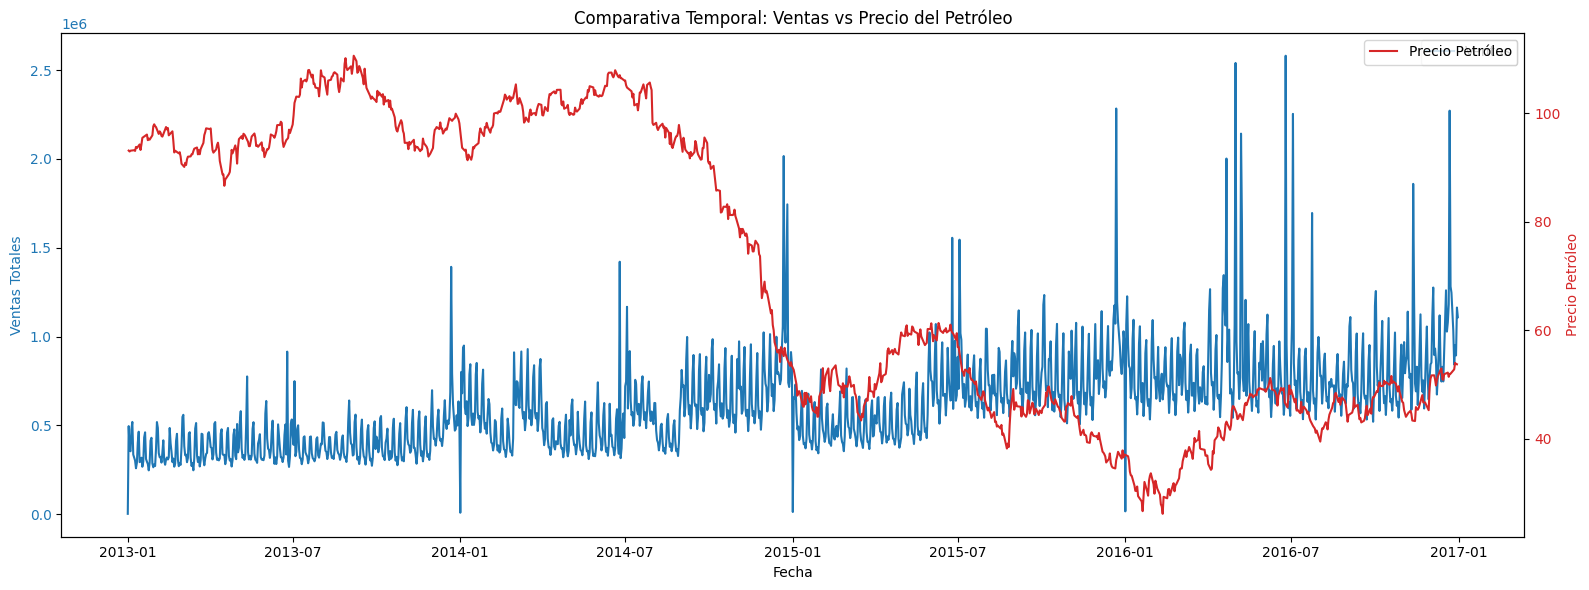

In [ ]:
# 1. Agrupamos por fecha para tener una visión clara de la serie temporal
# Asumiendo que tu columna de fecha se llama 'date'
df_temp = df_train.groupby('date').agg({'sales': 'sum', 'oil_price': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

# --- Primer Eje: Ventas ---
color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Ventas Totales', color=color)
sns.lineplot(data=df_temp, x='date', y='sales', ax=ax1, color=color, label='Ventas')
ax1.tick_params(axis='y', labelcolor=color)

# --- Segundo Eje: Petróleo ---
ax2 = ax1.twinx() # Crea un segundo eje que comparte el mismo eje X
color = 'tab:red'
ax2.set_ylabel('Precio Petróleo', color=color)
sns.lineplot(data=df_temp, x='date', y='oil_price', ax=ax2, color=color, label='Precio Petróleo')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparativa Temporal: Ventas vs Precio del Petróleo')
fig.tight_layout()
plt.show()

# Análisis Multivariable

In [ ]:
# Creamos un subset del dataframe original
df_corr = df_train[numeric_cols]

# 2. Calculamos las matrices de correlación
pearson_matrix = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')


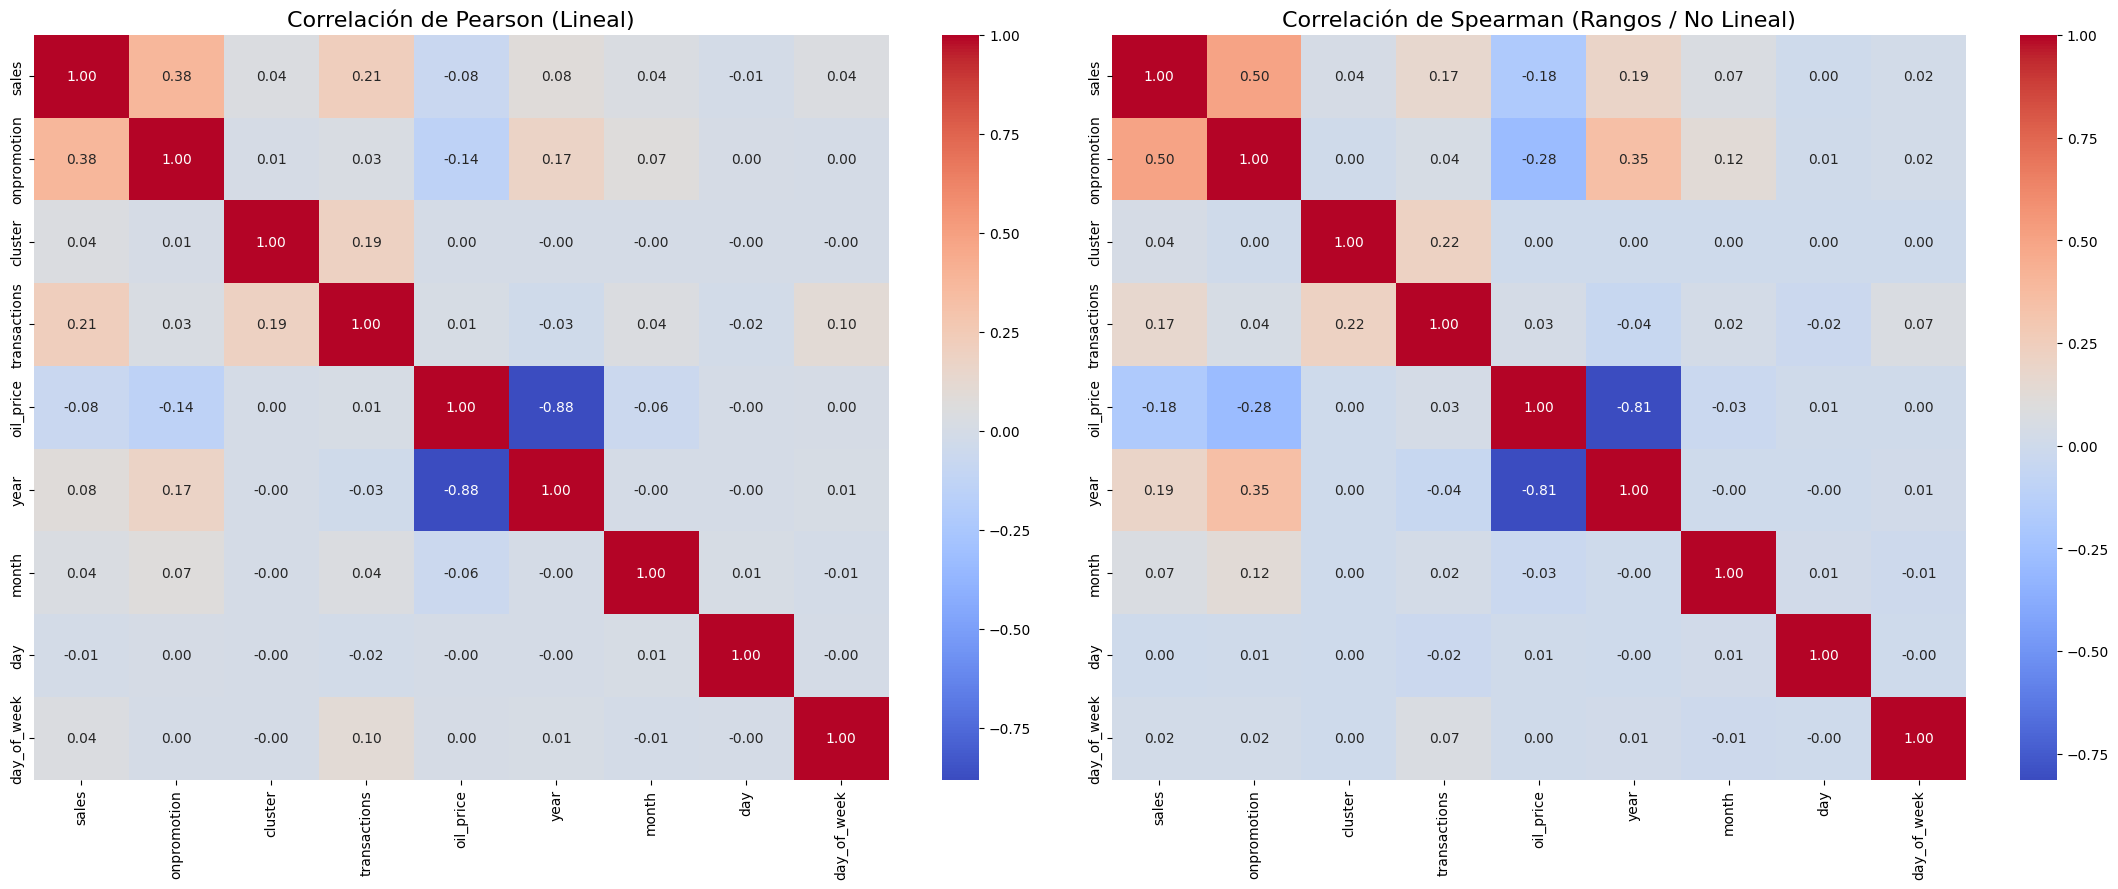

In [ ]:
# 3. Configuramos la figura con dos subplots (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap de Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0], cbar=True)
ax[0].set_title('Correlación de Pearson (Lineal)', fontsize=16)

# Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Correlación de Spearman (Rangos / No Lineal)', fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(spearman_matrix['sales'].sort_values(ascending=False))


--- Correlación de Spearman con el Fraude (is_fraud) ---
sales           1.000000
onpromotion     0.501814
year            0.194487
transactions    0.165605
month           0.068260
cluster         0.036987
day_of_week     0.020833
day             0.000657
oil_price      -0.178042
Name: sales, dtype: float64


In [ ]:
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(pearson_matrix['sales'].sort_values(ascending=False))

--- Correlación de Spearman con el Fraude (is_fraud) ---
sales           1.000000
onpromotion     0.380458
transactions    0.214337
year            0.077869
cluster         0.038873
day_of_week     0.037767
month           0.035258
day            -0.010748
oil_price      -0.077777
Name: sales, dtype: float64


In [ ]:
numeric_features = df_train.select_dtypes(include=['int','float64']).copy()
numeric_features.drop(columns = ['sales'], inplace=True, errors='ignore')

target = df_train["sales"] 

mi_numeric =mutual_info_regression(numeric_features, target, random_state=42)

mi_numeric_series = pd.Series(mi_numeric, index=numeric_features.columns).sort_values(ascending=False)

print("Info Mutua para numericas contra target: ")
print(mi_numeric_series)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

**Variables Categóricas**

In [ ]:
resultados = []

print("--- Análisis de Chi-Cuadrado vs is_fraud ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(df_train[col], df_train['sales'])
    
    # Calculamos Chi2 y el p-valor
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Interpretación
    dependiente = "SÍ (Significativa)" if p < 0.05 else "NO (Independiente)"
    
    resultados.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-valor': f"{p:.4e}", # Formato científico para p-valores muy pequeños
        'Relación con Fraude': dependiente
    })

# 2. Mostramos los resultados en una tabla limpia
df_chi = pd.DataFrame(resultados).sort_values(by='Chi2', ascending=False)
print(df_chi.to_string(index=False))


In [ ]:
def cramers_v(contingency_table):
    """ Calcula el coeficiente V de Cramer para una tabla de contingencia. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []

print("--- Análisis de Fuerza de Asociación (V de Cramer) ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia
    contingency_table = pd.crosstab(df_train[col], df_train['sales'])
    
    # Calculamos V de Cramer
    v = cramers_v(contingency_table)
    
    # Interpretación rápida de la fuerza
    if v > 0.5: fuerza = "Muy Fuerte"
    elif v > 0.3: fuerza = "Fuerte"
    elif v > 0.1: fuerza = "Moderada"
    else: fuerza = "Débil"
    
    resultados_v.append({
        'Variable': col,
        'Cramers V': round(v, 4),
        'Fuerza': fuerza
    })

# Mostramos resultados ordenados por fuerza
df_v = pd.DataFrame(resultados_v).sort_values(by='Cramers V', ascending=False)
print(df_v.to_string(index=False))